# Problem 3 Judge-Facing Split Notebook

이 notebook은 Problem 3의 최종 풀이를 제시한다. measurement-induced denoising, measurement-basis trade-off, two-way post-selection improvement, IBM Cloud mini validation을 포함한다. 실행 재현은 `../README.md`와 `../code/submission/run_all.py`를 따른다.

## Final Problem 3 Summary

- **Problem 3(a):** demonstrate measurement-induced denoising as a post-selected non-unitary map on the data system.
- **Problem 3(b):** analyze measurement-basis control as a recoverability-success-diversity trade-off, reporting \(\Delta D\), post-selection success probability \(p_{\mathrm{succ}}\), and diversity retention proxy \(R_{\mathrm{div}}\). The axis-only margin is small; the claim is the trade-off analysis, not continuous-basis dominance.
- **Problem 3(c):** use the 3-b analysis to test two-way Hamiltonian post-selection as a stronger but lower-success improvement.

**IBM Cloud validation callout for 3(b).** Tiny `M+F` measurement-basis sweep circuits were executed on `ibm_fez`. The higher-shot completed run shows \(p(F=0)\) changing from about `0.89` to `0.66` to `0.35` as \(\beta\) rotates, with selected-data entropy increasing. This validates hardware executability of the Problem 3(b) mechanism; it does not replace the state-vector benchmark and does not claim hardware advantage.


In [ ]:
!pip install -q qiskit qiskit-aer scipy numpy matplotlib

import numpy as np
import scipy.linalg as la
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, partial_trace, state_fidelity
from qiskit.circuit.library import RXGate, RYGate, RZGate, CXGate

print('Libraries loaded for this standalone problem notebook.')


In [ ]:
def generate_initial_ensemble(num_samples: int = 80, sigma: float = 0.10) -> list[Statevector]:
    """
    |00> 상태를 중심으로 미세한 각도 변위를 가진 양자 상태 앙상블을 생성합니다.

    Args:
        num_samples (int): 앙상블 크기 N (문제 조건: 50~100)
        sigma (float): 회전 각도를 추출할 정규분포의 표준편차
    Returns:
        list[Statevector]: 생성된 Statevector 객체들의 리스트
    """
    np.random.seed(2026)

    ensemble = []

    for _ in range(num_samples):
        qc = QuantumCircuit(2)

        for q in range(2):
            delta_y = np.random.normal(0, sigma)
            delta_z = np.random.normal(0, sigma)

            qc.ry(delta_y, q)
            qc.rz(delta_z, q)

        ensemble.append(Statevector(qc))

    return ensemble

N_SAMPLES = 80
SIGMA_VAL = 0.10

S_0 = generate_initial_ensemble(num_samples=N_SAMPLES, sigma=SIGMA_VAL)

print(f"✔ 앙상블 S_0 생성 완료 (총 {len(S_0)}개의 2-큐빗 상태벡터)")
print(f"  - 예시 상태벡터 0번의 기준 충실도 <00|psi_0> : {np.abs(S_0[0].data[0])**2:.4f}")


In [ ]:
def compute_pairwise_fidelity_matrix(ens1: list[Statevector], ens2: list[Statevector]) -> np.ndarray:
    """Compute pairwise fidelity F(psi, phi) = |<psi|phi>|^2 for two ensembles."""
    N1, N2 = len(ens1), len(ens2)
    F_matrix = np.zeros((N1, N2))
    for i in range(N1):
        for j in range(N2):
            F_matrix[i, j] = state_fidelity(ens1[i], ens2[j])
    return F_matrix

def compute_mmd_distance(ens_A: list[Statevector], ens_B: list[Statevector]) -> float:
    """
    Fidelity 커널 K(psi, phi) = |<psi|phi>|^2 을 이용한 MMD^2 거리를 계산합니다.
    MMD^2 = E[K(A,A)] - 2E[K(A,B)] + E[K(B,B)]
    """
    K_AA = compute_pairwise_fidelity_matrix(ens_A, ens_A)
    K_BB = compute_pairwise_fidelity_matrix(ens_B, ens_B)
    K_AB = compute_pairwise_fidelity_matrix(ens_A, ens_B)

    mmd_sq = np.mean(K_AA) - 2 * np.mean(K_AB) + np.mean(K_BB)
    return float(np.maximum(mmd_sq, 0.0))

def compute_wasserstein_distance(ens_A: list[Statevector], ens_B: list[Statevector]) -> float:
    """
    비충실도 Cost(psi, phi) = 1 - Fidelity 를 비용 함수로 사용하는 최적 운송(Optimal Transport) 거리를 계산합니다.
    (두 앙상블의 크기가 같으므로 헝가리안 알고리즘을 통해 일대일 매칭 최소 비용 연산)
    """
    F_AB = compute_pairwise_fidelity_matrix(ens_A, ens_B)
    cost_matrix = 1.0 - F_AB

    row_ind, col_ind = linear_sum_assignment(cost_matrix)
    total_cost = cost_matrix[row_ind, col_ind].sum()

    return float(total_cost / len(ens_A))

print("✔ MMD 거리 및 Wasserstein 거리 연산 엔진이 정의되었습니다.")


In [ ]:
def apply_random_unitary_layer(state: Statevector) -> Statevector:
    """One scrambling step: random single-qubit rotations plus one CX entangler."""
    qc = QuantumCircuit(2)
    qc.initialize(state.data, [0, 1])

    for q in range(2):
        qc.u(np.random.uniform(0, 2*np.pi), np.random.uniform(0, 2*np.pi), np.random.uniform(0, 2*np.pi), q)

    qc.cx(0, 1)
    return Statevector(qc)

STEPS_RU = 20
S_k_history = [S_0]

np.random.seed(42)
current_ensemble = S_0
for step in range(1, STEPS_RU + 1):
    next_ensemble = [apply_random_unitary_layer(psi) for psi in current_ensemble]
    S_k_history.append(next_ensemble)
    current_ensemble = next_ensemble

mmd_list_ru = [compute_mmd_distance(S_0, S_k) for S_k in S_k_history]
wass_list_ru = [compute_wasserstein_distance(S_0, S_k) for S_k in S_k_history]
print('Shared random-unitary trajectory prepared for downstream comparisons.')


In [ ]:
I = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)

def tensor_3(A, B, C):
    """3개의 2x2 행렬 텐서곱 (시스템 순서: Q0, Q1, Q2)"""
    return np.kron(np.kron(A, B), C)

h_x, h_y, J = 0.8090, 0.9045, 1.0

H = np.zeros((8, 8), dtype=complex)

H += h_x * tensor_3(X, I, I) + h_y * tensor_3(Y, I, I)
H += h_x * tensor_3(I, X, I) + h_y * tensor_3(I, Y, I)
H += h_x * tensor_3(I, I, X) + h_y * tensor_3(I, I, Y)

H += J * tensor_3(X, X, I)
H += J * tensor_3(I, X, X)

def get_hamiltonian_evolution_operator(t: float) -> np.ndarray:
    """주어진 시간 t에 대한 유니터리 행렬 U(t) = exp(-iHt) 계산"""
    return la.expm(-1j * H * t)

print("✔ 8x8 크기의 복합 해밀토니안(M+F) 행렬 구축 완료.")
print("  - 해밀토니안 에르미트성(Hermiticity) 검증:", np.allclose(H, H.conj().T))


In [ ]:
def generate_projected_ensemble(initial_M_ens: list[Statevector], t: float, num_projections: int = 80) -> list[Statevector]:
    """
    해밀토니안 시간 발전 후 보조 큐빗 F를 사영 측정하여 M 상의 유효 앙상블 S_t^Ham 을 생성합니다.
    """
    U_t = get_hamiltonian_evolution_operator(t)
    projected_ens = []

    for psi_M in initial_M_ens:
        psi_3 = np.kron(psi_M.data, np.array([1, 0], dtype=complex))
        evolved_psi = U_t @ psi_3

        vec_F = Statevector(QuantumCircuit(1).compose(RXGate(np.random.uniform(0, 2*np.pi)), [0])).data

        unnorm_M = np.zeros(4, dtype=complex)
        for idx_M in range(4):
            for idx_F in range(2):
                unnorm_M[idx_M] += evolved_psi[idx_M * 2 + idx_F] * np.conj(vec_F[idx_F])

        norm = la.norm(unnorm_M)
        if norm > 1e-9:
            projected_ens.append(Statevector(unnorm_M / norm))

    return projected_ens[:num_projections]

time_list = np.linspace(0, 15, 25)
S_t_ham_history = [S_0] + [generate_projected_ensemble(S_0, t) for t in time_list[1:]]

print(f"✔ 총 {len(time_list)}개의 시간 궤적에 대해 해밀토니안 사영 앙상블 도출 완료.")


## Problem 3(a). Simple Reverse / Denoising Step

문제 3(a)는 전체 trainable QuDDPM을 구현하는 것이 아니라, 작은 예제에서 reverse/denoising step을 보이는 것을 요구한다. 여기서는 문제 2의 `M+F` 구조를 사용하여 보조 큐빗 측정으로 data system에 effective non-unitary map을 만든다.


### [3번 전체 흐름 해설] a, b, c가 각각 하는 일

3번 문제 전체를 한 문장으로 말하면, **forward diffusion으로 흐트러진 양자 상태 ensemble을 측정 기반 post-selection으로 target ensemble 쪽으로 다시 당겨 보는 실험**이다.

- **3(a)**: 실제 reverse/denoising 한 스텝을 구현한다. noisy state `S_1`에 보조 큐빗 `|0>_F`를 붙이고, Hamiltonian으로 같이 진화시킨 뒤, 보조 큐빗을 특정 basis로 측정한다. 원하는 측정 결과가 나온 경우만 남기면 data state에는 \(K=\langle b|U|0\rangle\) 같은 effective non-unitary map이 작용한다. 이 `K`가 여기서 말하는 denoising filter이다.
- **3(b)**: 측정 basis를 바꾸면 결과가 어떻게 달라지는지 비교한다. `Z/X/Y` 축 방향 측정만 쓰는 baseline과, Bloch sphere 위 continuous basis까지 탐색하는 방법을 비교한다.
- **3(c)**: 3(a), 3(b)의 한계를 보고 개선안을 제안한다. 더 작은 1 data + 1 auxiliary toy, Hamiltonian path와 random kick 조합, 반복 recovery, target-aware amplitude filter 같은 후보를 같은 지표로 비교한다.

핵심 지표는 이렇게 읽으면 된다.

- `MMD`, `Wasserstein`: target `S_0`와 얼마나 먼지 보는 거리이다. **작을수록 좋고**, `improvement = before - after`는 **클수록 좋다**.
- `success_probability`: post-selection이 실제로 성공할 확률이다. 너무 낮으면 좋은 결과가 나와도 현실적으로 쓰기 어렵다.
- `diversity_retention`: ensemble이 한 상태로 과도하게 몰리지 않고 다양성을 유지했는지 보는 guardrail이다. 너무 낮으면 거리 지표만 좋아 보이는 결과일 수 있다.


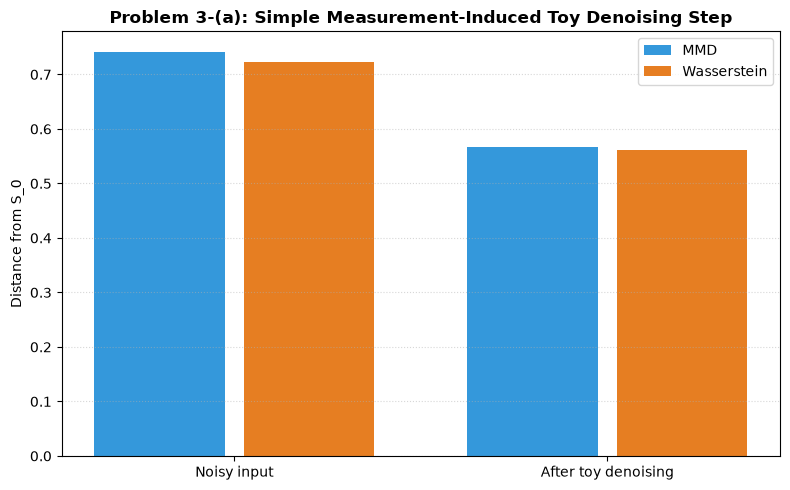

Problem 3-(a) 실행 결과
noisy step | searched candidates | valid candidates | selected basis | tau | theta | phi
S_1 | 336 | 336 | axis-X / x_minus | 1.721429 | 1.570796 | 3.141593
metric | before | after | improvement
MMD | 0.742012 | 0.566965 | 0.175046
Wasserstein | 0.722777 | 0.560883 | 0.161894
diversity retention | 0.810208
mean post-selection success probability | 0.471040


In [9]:
def measurement_basis_state(theta: float, phi: float) -> np.ndarray:
    """Bloch sphere 각도 (theta, phi)에 해당하는 1-qubit 측정 상태 |b(theta, phi)>를 반환합니다."""

    return np.array([
        np.cos(theta / 2.0),
        np.exp(1j * phi) * np.sin(theta / 2.0),
    ], dtype=complex)

def project_data_after_auxiliary_measurement(data_state: Statevector, tau: float, theta: float, phi: float, min_probability: float = 1e-12):
    """
    2-qubit data state |psi_M>에 complement qubit |0>_F를 붙인 뒤,
    3-qubit Hamiltonian으로 시간 tau만큼 진화시키고, F를 |b(theta, phi)>로 사영합니다.

    수식적으로는
        |psi'_M> ∝ <b(theta, phi)|_F exp(-i H tau) (|psi_M> ⊗ |0>_F)
    입니다. 따라서 output은 원래 data state가 그대로 append된 것이 아니라,
    보조 큐빗 측정 결과에 조건부로 정규화된 2-qubit 상태입니다.
    """

    aux_zero = np.array([1.0, 0.0], dtype=complex)

    psi_3 = np.kron(data_state.data, aux_zero)

    evolved = get_hamiltonian_evolution_operator(tau) @ psi_3

    basis = measurement_basis_state(theta, phi)

    unnormalized_data = np.zeros(4, dtype=complex)

    for idx_m in range(4):
        for idx_f in range(2):

            unnormalized_data[idx_m] += evolved[idx_m * 2 + idx_f] * np.conj(basis[idx_f])

    success_probability = float(np.vdot(unnormalized_data, unnormalized_data).real)
    norm = np.sqrt(max(success_probability, 0.0))

    if success_probability < min_probability:
        raise ValueError("post-selection probability below threshold")

    return Statevector(unnormalized_data / norm), success_probability

def apply_measurement_induced_denoising(ensemble, tau: float, theta: float, phi: float):
    """앙상블 전체에 같은 tau와 같은 측정 basis를 적용합니다."""

    denoised = []
    success_probabilities = []
    for state in ensemble:
        new_state, prob = project_data_after_auxiliary_measurement(state, tau, theta, phi)
        denoised.append(new_state)
        success_probabilities.append(prob)
    return denoised, np.array(success_probabilities, dtype=float)

def ensemble_diversity_score(ensemble) -> float:
    """앙상블 내부의 평균 pairwise infidelity로 diversity proxy를 계산합니다."""

    F = compute_pairwise_fidelity_matrix(ensemble, ensemble)
    if len(ensemble) <= 1:
        return 0.0
    mask = ~np.eye(len(ensemble), dtype=bool)
    return float(np.mean(1.0 - F[mask]))

S_noisy_p3 = S_k_history[1]

baseline_mmd_p3 = compute_mmd_distance(S_0, S_noisy_p3)
baseline_wass_p3 = compute_wasserstein_distance(S_0, S_noisy_p3)
baseline_div_p3 = ensemble_diversity_score(S_noisy_p3)

def is_axis_basis(theta: float, phi: float, atol: float = 1e-12) -> bool:
    if np.isclose(theta, 0.0, atol=atol) or np.isclose(theta, np.pi, atol=atol):
        return True
    if not np.isclose(theta, np.pi / 2.0, atol=atol):
        return False
    phi_mod = float(phi % (2.0 * np.pi))
    return any(np.isclose(phi_mod, axis_phi, atol=atol) for axis_phi in [0.0, np.pi / 2.0, np.pi, 3.0 * np.pi / 2.0])

def build_grounded_candidate_grid():
    tau_grid = np.linspace(0.05, 2.0, 8)

    basis_specs = [
        {"basis": "axis-Z", "basis_name": "z_plus", "theta": 0.0, "phi": 0.0},
        {"basis": "axis-Z", "basis_name": "z_minus", "theta": np.pi, "phi": 0.0},
        {"basis": "axis-X", "basis_name": "x_plus", "theta": np.pi / 2.0, "phi": 0.0},
        {"basis": "axis-X", "basis_name": "x_minus", "theta": np.pi / 2.0, "phi": np.pi},
        {"basis": "axis-Y", "basis_name": "y_plus", "theta": np.pi / 2.0, "phi": np.pi / 2.0},
        {"basis": "axis-Y", "basis_name": "y_minus", "theta": np.pi / 2.0, "phi": 3.0 * np.pi / 2.0},
    ]

    theta_grid = np.linspace(0.0, np.pi, 7)
    phi_grid = np.linspace(0.0, 2.0 * np.pi, 8, endpoint=False)
    for theta in theta_grid:
        if np.isclose(theta, 0.0) or np.isclose(theta, np.pi):
            continue
        for phi in phi_grid:
            if is_axis_basis(float(theta), float(phi)):
                continue
            basis_specs.append({
                "basis": "continuous-grid",
                "basis_name": "continuous-grid",
                "theta": float(theta),
                "phi": float(phi),
            })
    return tau_grid, basis_specs

tau_candidates, basis_candidates = build_grounded_candidate_grid()

problem3_candidate_rows = []
for tau in tau_candidates:
    for spec in basis_candidates:

        try:

            S_candidate, probs = apply_measurement_induced_denoising(S_noisy_p3, tau, spec["theta"], spec["phi"])
        except ValueError:
            continue

        mmd_after = compute_mmd_distance(S_0, S_candidate)
        wass_after = compute_wasserstein_distance(S_0, S_candidate)
        div_after = ensemble_diversity_score(S_candidate)

        diversity_retention = div_after / max(baseline_div_p3, 1e-12)

        mmd_improvement = baseline_mmd_p3 - mmd_after
        wass_improvement = baseline_wass_p3 - wass_after

        mean_success = float(np.mean(probs))

        score = mmd_improvement + wass_improvement + 0.05 * diversity_retention + 0.05 * mean_success
        problem3_candidate_rows.append({
            "basis": spec["basis"],
            "basis_name": spec["basis_name"],
            "tau": tau,
            "theta": spec["theta"],
            "phi": spec["phi"],
            "mmd_after": mmd_after,
            "wasserstein_after": wass_after,
            "mmd_improvement": mmd_improvement,
            "wasserstein_improvement": wass_improvement,
            "diversity_retention": diversity_retention,
            "mean_success_probability": mean_success,
            "score": score,
            "ensemble": S_candidate,
        })

if not problem3_candidate_rows:
    raise RuntimeError("No valid Problem 3-(a) candidates remained after post-selection probability filtering.")

eligible_rows_p3a = problem3_candidate_rows

best_p3a = max(problem3_candidate_rows, key=lambda row: row["score"])
S_denoised_p3 = best_p3a["ensemble"]

plt.figure(figsize=(8, 5))
labels = ["Noisy input", "After toy denoising"]
plt.bar([0, 1], [baseline_mmd_p3, best_p3a["mmd_after"]], width=0.35, label="MMD", color="#3498db")
plt.bar([0.4, 1.4], [baseline_wass_p3, best_p3a["wasserstein_after"]], width=0.35, label="Wasserstein", color="#e67e22")
plt.xticks([0.2, 1.2], labels)
plt.ylabel("Distance from S_0")
plt.title("Problem 3-(a): Simple Measurement-Induced Toy Denoising Step", fontweight="bold")
plt.grid(axis="y", linestyle=":", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

print("Problem 3-(a) 실행 결과")
print("noisy step | searched candidates | valid candidates | selected basis | tau | theta | phi")
print(
    f"S_1 | {len(tau_candidates) * len(basis_candidates)} | {len(problem3_candidate_rows)} | "
    f"{best_p3a['basis']} / {best_p3a['basis_name']} | {best_p3a['tau']:.6f} | "
    f"{best_p3a['theta']:.6f} | {best_p3a['phi']:.6f}"
)
print("metric | before | after | improvement")
print(f"MMD | {baseline_mmd_p3:.6f} | {best_p3a['mmd_after']:.6f} | {best_p3a['mmd_improvement']:.6f}")
print(f"Wasserstein | {baseline_wass_p3:.6f} | {best_p3a['wasserstein_after']:.6f} | {best_p3a['wasserstein_improvement']:.6f}")
print(f"diversity retention | {best_p3a['diversity_retention']:.6f}")
print(f"mean post-selection success probability | {best_p3a['mean_success_probability']:.6f}")


### [3(a) 디노이징 과정 해설] 이 코드가 실제로 하는 일

3(a)의 denoising은 classical image denoising처럼 픽셀을 직접 평균내는 과정이 아니다. 양자 상태에서는 상태벡터에 **측정으로 유도된 선형 필터**를 거는 방식으로 생각하면 된다.

흐름은 다음 순서이다.

1. noisy data state `|psi_M>`를 준비한다. 여기서는 `S_k_history[1]`, 즉 첫 번째 noisy ensemble `S_1`이다.
2. 보조 큐빗 `|0>_F`를 뒤에 붙여 `|psi_M> ⊗ |0>_F`를 만든다.
3. 문제 2에서 쓰던 Hamiltonian으로 전체 `M+F` 시스템을 `U(tau)=exp(-iHtau)`만큼 진화시킨다.
4. 보조 큐빗만 `|b(theta, phi)>` 방향으로 측정했다고 가정하고, 그 결과가 나온 경우만 post-selection한다.
5. The induced operation on the data system is the post-selected map below.

$$
K_{\tau,b} = (I_M \otimes \langle b|) e^{-iH\tau} (I_M \otimes |0\rangle_F).
$$

For each input state $|\psi_i\rangle_M$, the success probability and normalized post-selected state are

$$
p_{i,\tau,b} = \left\|K_{\tau,b}|\psi_i\rangle_M\right\|^2,
\qquad
|\phi_{i,\tau,b}\rangle =
\frac{K_{\tau,b}|\psi_i\rangle_M}{\sqrt{p_{i,\tau,b}}}.
$$
6. 이 `K`는 일반적으로 unitary가 아니라서 어떤 성분은 줄이고 어떤 성분은 키우는 filter처럼 작동한다. 그래서 target `S_0`에 더 가까워질 수 있다.
7. 여러 `tau`, `theta`, `phi` 후보를 훑고, MMD/Wasserstein 개선이 크면서 성공확률과 다양성도 나쁘지 않은 후보를 고른다.

즉, 3(a)의 핵심은 **보조 큐빗을 측정해서 data 쪽에 non-unitary correction을 간접적으로 만든다**는 점이다.


### Problem 3(a) 해석

Attach the auxiliary state $|0\rangle_F$ to each data state $|\psi_i\rangle_M$, evolve the joint system by $e^{-iH\tau}$, and condition on observing the auxiliary qubit in state $|b\rangle$. This induces the following map on the data system:

$$
K_{\tau,b} = (I_M \otimes \langle b|) e^{-iH\tau} (I_M \otimes |0\rangle_F)
$$

The normalized post-selected output is

$$
|\phi_{i,\tau,b}\rangle =
\frac{K_{\tau,b}|\psi_i\rangle_M}{\sqrt{p_{i,\tau,b}}},
\qquad
p_{i,\tau,b}=\left\|K_{\tau,b}|\psi_i\rangle_M\right\|^2.
$$

Although the joint `M+F` evolution is unitary, conditioning on the auxiliary measurement induces an effective non-unitary map on the data system.

보조 큐빗이 필요한 이유는 이 지점에 있다. Data qubit을 직접 측정하면 복원 대상 상태가 붕괴하지만, 보조 큐빗을 측정하면 data system에 조건부 변화를 유도할 수 있다. 또한 unitary만으로는 norm 보존 때문에 특정 성분을 선택적으로 수축시키기 어렵지만, post-selected non-unitary map은 denoising filter로 작동할 수 있다.


### Problem 3(a) 발표용 시각화


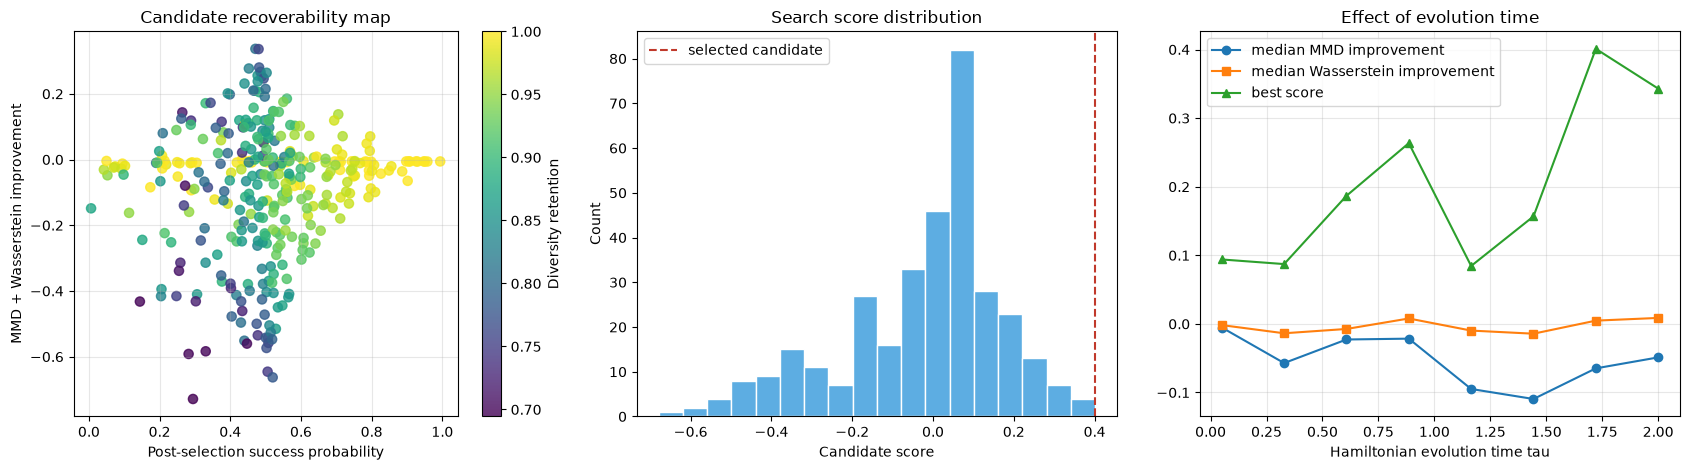

In [10]:
candidate_scores = np.array([row["score"] for row in problem3_candidate_rows])
candidate_success = np.array([row["mean_success_probability"] for row in problem3_candidate_rows])
candidate_diversity = np.array([row["diversity_retention"] for row in problem3_candidate_rows])
candidate_mmd_gain = np.array([row["mmd_improvement"] for row in problem3_candidate_rows])
candidate_wass_gain = np.array([row["wasserstein_improvement"] for row in problem3_candidate_rows])
candidate_tau = np.array([row["tau"] for row in problem3_candidate_rows])

tau_values = sorted(set(candidate_tau))
tau_median_mmd = []
tau_median_wass = []
tau_best_score = []
for tau in tau_values:
    rows = [row for row in problem3_candidate_rows if np.isclose(row["tau"], tau)]
    tau_median_mmd.append(np.median([row["mmd_improvement"] for row in rows]))
    tau_median_wass.append(np.median([row["wasserstein_improvement"] for row in rows]))
    tau_best_score.append(max(row["score"] for row in rows))

fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))

scatter = axes[0].scatter(
    candidate_success,
    candidate_mmd_gain + candidate_wass_gain,
    c=candidate_diversity,
    cmap="viridis",
    s=44,
    alpha=0.8,
)
axes[0].set_xlabel("Post-selection success probability")
axes[0].set_ylabel("MMD + Wasserstein improvement")
axes[0].set_title("Candidate recoverability map")
axes[0].grid(alpha=0.3)
fig.colorbar(scatter, ax=axes[0], label="Diversity retention")

axes[1].hist(candidate_scores, bins=18, color="#5dade2", edgecolor="white")
axes[1].axvline(best_p3a["score"], color="#c0392b", linestyle="--", label="selected candidate")
axes[1].set_xlabel("Candidate score")
axes[1].set_ylabel("Count")
axes[1].set_title("Search score distribution")
axes[1].legend()

axes[2].plot(tau_values, tau_median_mmd, marker="o", label="median MMD improvement")
axes[2].plot(tau_values, tau_median_wass, marker="s", label="median Wasserstein improvement")
axes[2].plot(tau_values, tau_best_score, marker="^", label="best score")
axes[2].set_xlabel("Hamiltonian evolution time tau")
axes[2].set_title("Effect of evolution time")
axes[2].grid(alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()


## Problem 3(b). Controlled Modification and Trade-off

문제 전문에서 3(b)는 denoising 자체를 더 깊게 만들라는 요구가 아니라, **diffusion setting을 통제된 방식으로 바꾸고 그 영향과 trade-off를 분석하라**는 요구이다. 따라서 여기서는 문제 2의 Hamiltonian projected diffusion을 기준으로 삼고, 한 번에 하나의 제어 변수를 바꾸어 비교한다.

바꾼 제어 변수와 이유는 다음과 같다.

| 변경 항목 | 선택 이유 | 기대 효과 | 예상 손실 |
| --- | --- | --- | --- |
| interaction strength `J` 감소/증가 | data-complement 얽힘 강도를 직접 바꾸는 가장 해석 가능한 Hamiltonian parameter | diffusion 속도와 scrambling 정도 조절 | 너무 작으면 diffusion이 약하고, 너무 크면 fluctuation이나 projection instability 증가 |
| evolution schedule 길이 변경 | 같은 fixed Hamiltonian에서도 관측 시간 구간이 다르면 saturation 여부가 달라짐 | 짧은 schedule은 안정적, 긴 schedule은 더 강한 diffusion 탐색 가능 | 짧으면 충분히 퍼지지 않고, 길면 과도한 fluctuation 가능 |
| measurement basis 변경 | projected ensemble construction에서 complement qubit을 어떤 방향으로 조건부 선택하는지가 data ensemble을 바꿈 | 특정 basis가 더 강한 projected diffusion을 만들 수 있음 | 성공확률 또는 diversity가 낮아질 수 있음 |
| simple coherent phase noise 추가 | near-term hardware에서 작은 phase error가 누적되는 상황을 toy로 반영 | hardware-facing robustness 확인 | target과의 거리 증가 및 해석 난이도 증가 |

비교 기준은 문제 1, 2와 동일하게 fidelity 기반 MMD^2와 infidelity-cost Wasserstein-type distance이다. 여기서는 거리가 커지는 것이 항상 “좋다”는 뜻은 아니다. Diffusion 문제에서는 target cluster를 얼마나 흐트러뜨리는지 보는 지표이고, 동시에 fluctuation, diversity, post-selection success probability를 함께 봐야 한다.


### IBM Cloud validation callout for Problem 3(b)

Tiny `M+F` measurement-basis sweep circuits were executed on IBM Quantum / Qiskit Runtime using backend `ibm_fez`. The higher-shot completed run (`4096` shots x `20` circuits) shows that the complement-qubit basis angle changes both post-selection statistics and the selected data distribution:

| beta | mean p(F=0) | mean selected-data entropy |
|---:|---:|---:|
| `0.0000pi` | `0.881738` | `1.375447` |
| `0.2500pi` | `0.893164` | `1.492915` |
| `0.5000pi` | `0.661377` | `1.581403` |
| `0.7500pi` | `0.351270` | `1.736465` |

This is a hardware-execution validation of the tiny Problem 3(b) mechanism. The main quantitative benchmark remains state-vector based, and no hardware advantage or IBM superiority is claimed. The executable IBM appendix path is kept in `IBM_QPU_Implementation.ipynb` and `../code/ibm_qpu/`; archived raw supporting outputs are separated under `../../usb_package_supporting_materials/archive/`.


Problem 3-(b) controlled diffusion setting comparison
setting | reason | max MMD | max W | final MMD | final W | median diversity | median success | improved | sacrificed
Hamiltonian projected diffusion under fixed H (Problem 2 baseline) | 문제 2의 hx, hy, J를 유지해 비교 기준을 만든다. | 1.945750 | 0.980862 | 0.984855 | 0.498875 | 0.008617 | 0.556580 | reference level | no major loss
weaker coupling J=0.5 | M-F 얽힘을 약하게 하여 더 부드러운 diffusion이 가능한지 확인한다. | 1.741870 | 0.878824 | 0.443177 | 0.226166 | 0.007732 | 0.556137 | reference level | weaker diffusion, more fluctuation
stronger coupling J=1.5 | M-F 얽힘을 강하게 하여 더 빠른 scrambling이 생기는지 확인한다. | 1.959276 | 0.989975 | 1.695887 | 0.859116 | 0.009988 | 0.465999 | smoother trajectory | lower post-selection success
short schedule t<=4 | 같은 Hamiltonian에서 짧은 관측 구간이 안정성을 주는지 확인한다. | 1.864173 | 0.941389 | 1.864173 | 0.941389 | 0.009988 | 0.491280 | smoother trajectory | weaker diffusion, lower post-selection success
continuous measurement basis | 보조 큐빗 측정 방향을 Z축에서 

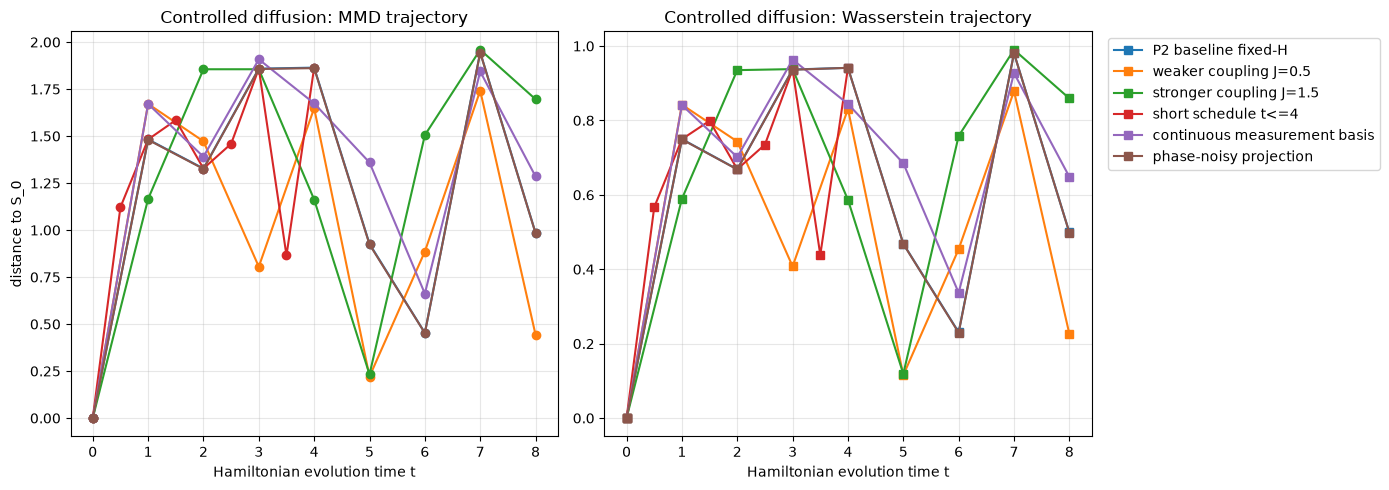

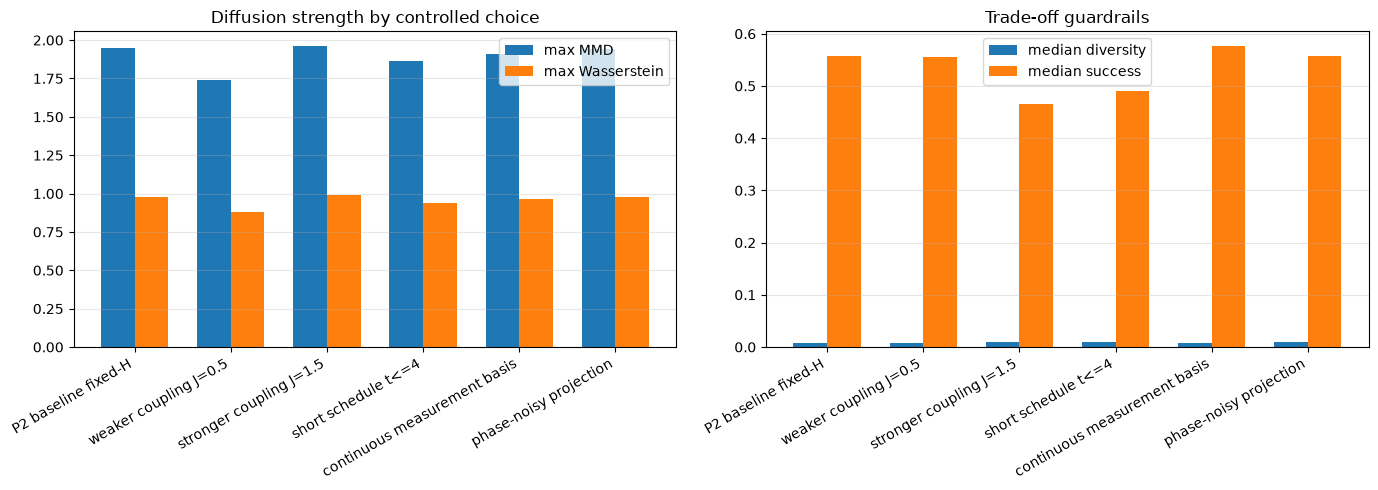


Problem 3-(b) measurement-basis ablation
comparison | basis | tau | theta | phi | MMD improvement | W improvement | diversity | success | score
best axis-only | axis-X / x_minus | 1.721429 | 1.570796 | 3.141593 | 0.175046 | 0.161894 | 0.810208 | 0.471040 | 0.401003
best continuous-grid | continuous-grid / continuous-grid | 1.721429 | 2.094395 | 3.141593 | 0.161776 | 0.174429 | 0.757273 | 0.480035 | 0.398070
continuous-vs-axis score margin | -0.002933


In [11]:
def build_three_qubit_hamiltonian(hx=0.8090, hy=0.9045, j=1.0):
    H_local = np.zeros((8, 8), dtype=complex)
    H_local += hx * tensor_3(X, I, I) + hy * tensor_3(Y, I, I)
    H_local += hx * tensor_3(I, X, I) + hy * tensor_3(I, Y, I)
    H_local += hx * tensor_3(I, I, X) + hy * tensor_3(I, I, Y)
    H_local += j * tensor_3(X, X, I)
    H_local += j * tensor_3(I, X, X)
    return H_local

def projection_basis_named(name):
    if name == "Z0":
        return np.array([1.0, 0.0], dtype=complex)
    if name == "X+":
        return np.array([1.0, 1.0], dtype=complex) / np.sqrt(2.0)
    if name == "Y+":
        return np.array([1.0, 1.0j], dtype=complex) / np.sqrt(2.0)
    if name == "continuous-best":
        return measurement_basis_state(best_p3a["theta"], best_p3a["phi"])
    raise ValueError(f"unknown basis: {name}")

def apply_small_phase_noise(state, strength, rng):
    if strength <= 0.0:
        return state
    qc = QuantumCircuit(2)
    qc.initialize(state.data, [0, 1])
    qc.rz(float(rng.normal(0.0, strength)), 0)
    qc.rz(float(rng.normal(0.0, strength)), 1)
    return Statevector(qc)

def projected_ensemble_controlled(initial_ensemble, t, hamiltonian, basis, noise_strength=0.0, seed=0):
    U_t = la.expm(-1j * hamiltonian * t)
    rng = np.random.default_rng(seed)
    projected = []
    probabilities = []
    for sample_index, psi_M in enumerate(initial_ensemble):
        psi_3 = np.kron(psi_M.data, np.array([1.0, 0.0], dtype=complex))
        evolved = U_t @ psi_3
        unnorm_M = np.zeros(4, dtype=complex)
        for idx_M in range(4):
            for idx_F in range(2):
                unnorm_M[idx_M] += evolved[idx_M * 2 + idx_F] * np.conj(basis[idx_F])
        probability = float(np.vdot(unnorm_M, unnorm_M).real)
        if probability <= 1e-12:
            continue
        state = Statevector(unnorm_M / np.sqrt(probability))
        state = apply_small_phase_noise(state, noise_strength, rng)
        projected.append(state)
        probabilities.append(probability)
    if len(projected) == 0:
        raise RuntimeError("no valid projected states")
    return projected, float(np.mean(probabilities))

controlled_time_grid = np.linspace(0.0, 8.0, 9)

controlled_settings_3b = [
    {
        "name": "Hamiltonian projected diffusion under fixed H (Problem 2 baseline)",
        "reason": "문제 2의 hx, hy, J를 유지해 비교 기준을 만든다.",
        "hamiltonian": build_three_qubit_hamiltonian(j=1.0),
        "basis": "Z0",
        "times": controlled_time_grid,
        "noise": 0.0,
    },
    {
        "name": "weaker coupling J=0.5",
        "reason": "M-F 얽힘을 약하게 하여 더 부드러운 diffusion이 가능한지 확인한다.",
        "hamiltonian": build_three_qubit_hamiltonian(j=0.5),
        "basis": "Z0",
        "times": controlled_time_grid,
        "noise": 0.0,
    },
    {
        "name": "stronger coupling J=1.5",
        "reason": "M-F 얽힘을 강하게 하여 더 빠른 scrambling이 생기는지 확인한다.",
        "hamiltonian": build_three_qubit_hamiltonian(j=1.5),
        "basis": "Z0",
        "times": controlled_time_grid,
        "noise": 0.0,
    },
    {
        "name": "short schedule t<=4",
        "reason": "같은 Hamiltonian에서 짧은 관측 구간이 안정성을 주는지 확인한다.",
        "hamiltonian": build_three_qubit_hamiltonian(j=1.0),
        "basis": "Z0",
        "times": np.linspace(0.0, 4.0, 9),
        "noise": 0.0,
    },
    {
        "name": "continuous measurement basis",
        "reason": "보조 큐빗 측정 방향을 Z축에서 3(a)의 best continuous basis로 바꾸어 projection 자유도의 효과를 본다.",
        "hamiltonian": build_three_qubit_hamiltonian(j=1.0),
        "basis": "continuous-best",
        "times": controlled_time_grid,
        "noise": 0.0,
    },
    {
        "name": "phase-noisy projection",
        "reason": "작은 coherent phase noise가 projected diffusion 지표를 얼마나 악화시키는지 확인한다.",
        "hamiltonian": build_three_qubit_hamiltonian(j=1.0),
        "basis": "Z0",
        "times": controlled_time_grid,
        "noise": 0.05,
    },
]

controlled_rows_3b = []
controlled_summary_3b = []

for setting in controlled_settings_3b:
    distances_mmd = []
    distances_w = []
    diversities = []
    successes = []
    basis = projection_basis_named(setting["basis"])
    for time_index, t in enumerate(setting["times"]):
        if np.isclose(t, 0.0):
            ensemble_t = S_0
            success = 1.0
        else:
            ensemble_t, success = projected_ensemble_controlled(
                S_0,
                float(t),
                setting["hamiltonian"],
                basis,
                noise_strength=setting["noise"],
                seed=2026 + time_index,
            )
        mmd_value = compute_mmd_distance(S_0, ensemble_t)
        wasserstein_value = compute_wasserstein_distance(S_0, ensemble_t)
        diversity_value = ensemble_diversity_score(ensemble_t)
        distances_mmd.append(mmd_value)
        distances_w.append(wasserstein_value)
        diversities.append(diversity_value)
        successes.append(success)
        controlled_rows_3b.append({
            "setting": setting["name"],
            "time": float(t),
            "mmd": mmd_value,
            "wasserstein": wasserstein_value,
            "diversity": diversity_value,
            "success_probability": success,
        })

    roughness = float(np.std(np.diff(distances_mmd))) if len(distances_mmd) > 1 else 0.0
    controlled_summary_3b.append({
        "setting": setting["name"],
        "reason": setting["reason"],
        "basis": setting["basis"],
        "noise": setting["noise"],
        "max_time": float(max(setting["times"])),
        "final_mmd": float(distances_mmd[-1]),
        "max_mmd": float(max(distances_mmd)),
        "final_wasserstein": float(distances_w[-1]),
        "max_wasserstein": float(max(distances_w)),
        "median_diversity": float(np.median(diversities)),
        "median_success": float(np.median(successes)),
        "roughness": roughness,
    })

baseline_3b = controlled_summary_3b[0]

def tradeoff_text(row, baseline):
    improved = []
    sacrificed = []
    if row["max_mmd"] > baseline["max_mmd"] + 0.03:
        improved.append("stronger diffusion")
    elif row["max_mmd"] < baseline["max_mmd"] - 0.03:
        sacrificed.append("weaker diffusion")
    if row["roughness"] < baseline["roughness"] - 0.005:
        improved.append("smoother trajectory")
    elif row["roughness"] > baseline["roughness"] + 0.005:
        sacrificed.append("more fluctuation")
    if row["median_diversity"] > baseline["median_diversity"] + 0.02:
        improved.append("higher diversity")
    elif row["median_diversity"] < baseline["median_diversity"] - 0.02:
        sacrificed.append("lower diversity")
    if row["median_success"] > baseline["median_success"] + 0.02:
        improved.append("higher post-selection success")
    elif row["median_success"] < baseline["median_success"] - 0.02:
        sacrificed.append("lower post-selection success")
    if not improved:
        improved.append("reference level")
    if not sacrificed:
        sacrificed.append("no major loss")
    return ", ".join(improved), ", ".join(sacrificed)

print("Problem 3-(b) controlled diffusion setting comparison")
print("setting | reason | max MMD | max W | final MMD | final W | median diversity | median success | improved | sacrificed")
for row in controlled_summary_3b:
    improved, sacrificed = tradeoff_text(row, baseline_3b)
    print(
        f"{row['setting']} | {row['reason']} | {row['max_mmd']:.6f} | {row['max_wasserstein']:.6f} | "
        f"{row['final_mmd']:.6f} | {row['final_wasserstein']:.6f} | {row['median_diversity']:.6f} | "
        f"{row['median_success']:.6f} | {improved} | {sacrificed}"
    )

print("\nProblem 1/2 baseline references")
print(f"Problem 1 random-unitary final k={STEPS_RU}: MMD={mmd_list_ru[-1]:.6f}, Wasserstein={wass_list_ru[-1]:.6f}")
print(f"Problem 2 original Hamiltonian final t={time_list[-1]:.2f}: MMD={mmd_ham[-1]:.6f}, Wasserstein={wass_ham[-1]:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for setting in controlled_settings_3b:
    rows = [row for row in controlled_rows_3b if row["setting"] == setting["name"]]
    axes[0].plot([row["time"] for row in rows], [row["mmd"] for row in rows], marker="o", label=setting["name"])
    axes[1].plot([row["time"] for row in rows], [row["wasserstein"] for row in rows], marker="s", label=setting["name"])
axes[0].set_title("Controlled diffusion: MMD trajectory")
axes[0].set_xlabel("Hamiltonian evolution time t")
axes[0].set_ylabel("distance to S_0")
axes[0].grid(alpha=0.3)
axes[1].set_title("Controlled diffusion: Wasserstein trajectory")
axes[1].set_xlabel("Hamiltonian evolution time t")
axes[1].grid(alpha=0.3)
axes[1].legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

setting_labels = [row["setting"] for row in controlled_summary_3b]
x = np.arange(len(setting_labels))
width = 0.35
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(x - width / 2, [row["max_mmd"] for row in controlled_summary_3b], width, label="max MMD")
axes[0].bar(x + width / 2, [row["max_wasserstein"] for row in controlled_summary_3b], width, label="max Wasserstein")
axes[0].set_xticks(x)
axes[0].set_xticklabels(setting_labels, rotation=30, ha="right")
axes[0].set_title("Diffusion strength by controlled choice")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)
axes[1].bar(x - width / 2, [row["median_diversity"] for row in controlled_summary_3b], width, label="median diversity")
axes[1].bar(x + width / 2, [row["median_success"] for row in controlled_summary_3b], width, label="median success")
axes[1].set_xticks(x)
axes[1].set_xticklabels(setting_labels, rotation=30, ha="right")
axes[1].set_title("Trade-off guardrails")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

basis_summary_rows_3b = []
for row in problem3_candidate_rows:
    basis_summary_rows_3b.append({
        "basis": row["basis"],
        "basis_name": row["basis_name"],
        "theta": row["theta"],
        "phi": row["phi"],
        "tau": row["tau"],
        "mmd_improvement": row["mmd_improvement"],
        "wasserstein_improvement": row["wasserstein_improvement"],
        "diversity_retention": row["diversity_retention"],
        "success_probability": row["mean_success_probability"],
        "score": row["score"],
    })

best_by_basis_3b = []
for family in ["axis-Z", "axis-X", "axis-Y", "continuous-grid"]:
    family_rows = [row for row in basis_summary_rows_3b if row["basis"] == family]
    best_by_basis_3b.append(max(family_rows, key=lambda row: row["score"]))

best_axis = max([row for row in best_by_basis_3b if row["basis"].startswith("axis")], key=lambda row: row["score"])
best_continuous = max([row for row in best_by_basis_3b if row["basis"].startswith("continuous")], key=lambda row: row["score"])
axis_to_continuous_margin = best_continuous["score"] - best_axis["score"]

print("\nProblem 3-(b) measurement-basis ablation")
print("comparison | basis | tau | theta | phi | MMD improvement | W improvement | diversity | success | score")
for label, row in [("best axis-only", best_axis), ("best continuous-grid", best_continuous)]:
    print(
        f"{label} | {row['basis']} / {row['basis_name']} | {row['tau']:.6f} | {row['theta']:.6f} | "
        f"{row['phi']:.6f} | {row['mmd_improvement']:.6f} | {row['wasserstein_improvement']:.6f} | "
        f"{row['diversity_retention']:.6f} | {row['success_probability']:.6f} | {row['score']:.6f}"
    )
print(f"continuous-vs-axis score margin | {axis_to_continuous_margin:+.6f}")


### Problem 3(b) 해석

3(b)의 핵심은 denoising 성능 하나를 키우는 것이 아니라, diffusion setting의 제어 변수를 바꾸었을 때 어떤 물리적 효과와 비용이 생기는지 보는 것이다.

`J`를 키우면 data system과 complement qubit 사이의 상호작용이 강해져 더 빠른 diffusion 또는 더 큰 거리 증가가 나타날 수 있다. 하지만 거리 증가가 크다는 것은 target cluster가 더 강하게 흐트러진다는 뜻이기도 하므로, reverse 과정에서는 더 어려운 입력을 만들 수 있다. 반대로 `J`를 낮추면 trajectory가 부드럽고 안정적으로 보일 수 있지만 diffusion strength가 약해질 수 있다.

짧은 evolution schedule은 과도한 fluctuation을 줄이는 장점이 있지만 충분한 scrambling에 도달하지 못할 수 있다. Measurement basis를 바꾸는 경우에는 projected ensemble의 방향성을 조절할 수 있지만, post-selection success probability와 diversity retention을 함께 확인해야 한다. Simple phase noise를 넣은 경우는 실제 하드웨어 환경을 향한 보수적 확인이며, 대체로 target distance를 키우거나 trajectory를 불안정하게 만드는 손실이 있다.

따라서 3(b)의 결론은 특정 parameter가 항상 우월하다는 것이 아니다. 우리는 같은 metric 위에서 `diffusion strength`, `trajectory fluctuation`, `diversity`, `post-selection success probability`를 함께 비교했고, 각 선택이 무엇을 개선하고 무엇을 희생하는지 분리해 제시했다.


## Problem 3(c). 후보 포트폴리오와 최종 선택

문제 3(c)는 하나의 방법만 제시하는 항목이 아니라, 3(a), 3(b)에서 얻은 reverse/denoising 구조를 바탕으로 여러 개선 후보를 제안하고 작은 예제에서 비교하는 항목이다.

따라서 본 보고서에서는 다음 후보를 함께 둔다.

| 후보 | 역할 | 비교 방식 |
| --- | --- | --- |
| no-denoising input | reverse step을 하지 않은 기준점 | target과의 거리 |
| axis-only projection | Z/X/Y 측정 기저만 쓰는 대조군 | 3(b)의 통제 비교 |
| continuous post-selection | 3(a), 3(b)의 main denoising proxy | 거리 개선, 다양성, 성공확률 |
| Hamiltonian + random final kick | Hamiltonian post-selection 뒤 작은 random-unitary correction을 붙인 mixture 후보 | 3(c) 실행 후보 |
| Hamiltonian two-way post-selection | Hamiltonian post-selection을 두 단계로 적용하는 후보 | 3(c) 실행 후보 |
| hybrid 1M+1F toy | 보조 큐빗 측정 구조를 2-qubit scale로 줄인 하드웨어 동기 후보 | 작은 toy 실행 |
| target-aware actor-critic | raw target reward를 쓰는 정책 탐색 후보 | 여러 seed에서 continuous baseline과 비교 |

최종 결론은 actor-critic 하나가 아니라, 후보군을 비교한 뒤 claim 범위를 나누는 방식으로 제시한다. 최종 본문 후보 포트폴리오에는 실제 실행 후보와 대조군만 포함한다.


### Problem 3(c) 후보: Target-Aware Actor-Critic

Actor-Critic 후보는 `K_lambda = diag(1, lambda, lambda, lambda)` 형태의 non-unitary filter strength를 정책이 선택하게 만드는 실험이다. 이 방법은 raw target ensemble을 reward 계산에 사용하므로 성능이 좋아도 unknown-target 일반 denoiser라고 주장하지 않는다.


### Problem 3(c) 실행 파트 1: Actor-Critic 공통 함수


In [12]:
def ensemble_to_matrix(ensemble):
    """Statevector 리스트를 (N, 4) 복소수 행렬로 바꿉니다."""
    return np.vstack([state.data for state in ensemble]).astype(complex)

def matrix_to_ensemble(states):
    """(N, 4) 상태 행렬을 Statevector 리스트로 되돌립니다."""
    return [Statevector(row) for row in states]

def normalize_rows(states):
    """각 sample state의 norm이 1이 되도록 정규화합니다."""
    states = np.asarray(states, dtype=complex)
    norms = np.linalg.norm(states, axis=1, keepdims=True)
    return states / np.maximum(norms, 1e-15)

def fidelity_matrix_np(left, right):
    """두 ensemble 사이의 pairwise fidelity 행렬을 계산합니다."""
    left = normalize_rows(left)
    right = normalize_rows(right)
    return np.clip(np.abs(left @ right.conj().T) ** 2, 0.0, 1.0)

def mmd_distance_np(left, right):
    """보고서 앞부분과 같은 fidelity-kernel MMD^2를 계산합니다."""
    k_xx = fidelity_matrix_np(left, left)
    k_yy = fidelity_matrix_np(right, right)
    k_xy = fidelity_matrix_np(left, right)
    return float(max(k_xx.mean() + k_yy.mean() - 2.0 * k_xy.mean(), 0.0))

def wasserstein_distance_np(left, right):
    """cost = 1 - fidelity인 일대일 matching Wasserstein-type distance를 계산합니다."""
    cost = 1.0 - fidelity_matrix_np(left, right)
    row_ind, col_ind = linear_sum_assignment(cost)
    return float(cost[row_ind, col_ind].mean())

def diversity_np(states):
    """ensemble 내부 sample들이 서로 얼마나 떨어져 있는지 보는 diversity proxy입니다."""
    fidelities = fidelity_matrix_np(states, states)
    mask = ~np.eye(len(states), dtype=bool)
    return float((1.0 - fidelities)[mask].mean())

def target_aware_filter_np(states, lambda_value):
    """K_lambda = diag(1, lambda, lambda, lambda)를 적용하고 성공확률을 반환합니다."""
    diagonal = np.array([1.0, lambda_value, lambda_value, lambda_value], dtype=complex)
    raw = states * diagonal[None, :]
    probabilities = np.sum(np.abs(raw) ** 2, axis=1).real
    return normalize_rows(raw), probabilities

def summarize_candidate_np(label, target, noisy, candidate, success_probability):
    """후보 denoising 결과를 같은 기준의 한 줄 metric으로 정리합니다."""
    baseline_mmd = mmd_distance_np(target, noisy)
    baseline_wass = wasserstein_distance_np(target, noisy)
    candidate_mmd = mmd_distance_np(target, candidate)
    candidate_wass = wasserstein_distance_np(target, candidate)
    return {
        "label": label,
        "baseline_mmd": baseline_mmd,
        "candidate_mmd": candidate_mmd,
        "mmd_reduction": baseline_mmd - candidate_mmd,
        "baseline_wasserstein": baseline_wass,
        "candidate_wasserstein": candidate_wass,
        "wasserstein_reduction": baseline_wass - candidate_wass,
        "raw_fidelity": 1.0 - candidate_wass,
        "raw_fidelity_gain": baseline_wass - candidate_wass,
        "diversity_retention": diversity_np(candidate) / max(diversity_np(noisy), 1e-12),
        "success_probability": float(success_probability),
    }

def softmax(logits):
    """actor가 낸 logit을 action probability로 바꿉니다."""
    logits = np.asarray(logits, dtype=float)
    shifted = logits - np.max(logits)
    values = np.exp(shifted)
    return values / values.sum()


### Problem 3(c) 후보: Hybrid 1M+1F Toy

이 후보는 data qubit 1개와 auxiliary qubit 1개만 사용한다. Random-unitary로 흐트러진 1-qubit data를 Hamiltonian-inspired 2-qubit block에 넣고, auxiliary qubit을 측정해 post-selection한다. 본문에서는 실제 하드웨어 우위가 아니라, 보조 큐빗 측정 기반 denoising 구조가 가장 작은 회로 규모에서도 표현 가능하다는 보조 근거로 사용한다.


Problem 3-(c) Hybrid 1M+1F toy
input step | MMD before | MMD after | W before | W after | diversity | success
         1 | 0.591580 | 0.078011 | 0.485182 | 0.136448 | 0.565030 | 0.582736
         2 | 0.528267 | 0.253203 | 0.489991 | 0.248479 | 0.576728 | 0.469309
         4 | 0.461424 | 0.226294 | 0.453689 | 0.224235 | 0.528366 | 0.550901


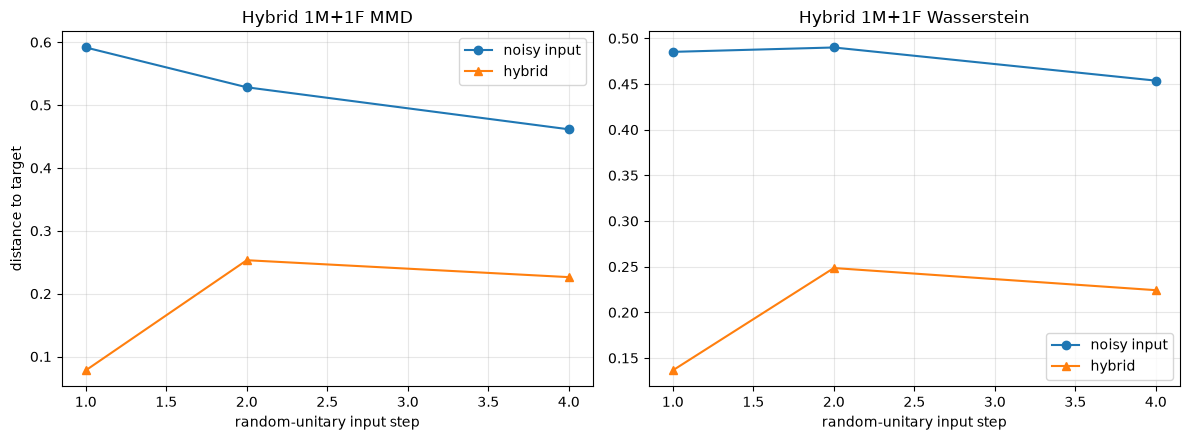

In [13]:
KET0_1Q = np.array([1.0, 0.0], dtype=complex)
I_1Q = np.eye(2, dtype=complex)
X_1Q = np.array([[0, 1], [1, 0]], dtype=complex)
Y_1Q = np.array([[0, -1j], [1j, 0]], dtype=complex)

def ry_1q(theta):
    c = np.cos(theta / 2.0)
    s = np.sin(theta / 2.0)
    return np.array([[c, -s], [s, c]], dtype=complex)

def rz_1q(theta):
    return np.array([[np.exp(-0.5j * theta), 0.0], [0.0, np.exp(0.5j * theta)]], dtype=complex)

def rx_1q(theta):
    c = np.cos(theta / 2.0)
    s = np.sin(theta / 2.0)
    return np.array([[c, -1j * s], [-1j * s, c]], dtype=complex)

def normalize_1q_rows(states):
    states = np.asarray(states, dtype=complex)
    norms = np.linalg.norm(states, axis=1, keepdims=True)
    return states / np.maximum(norms, 1e-15)

def target_1q_ensemble(num_samples=40, sigma=0.10, seed=2026):
    rng = np.random.default_rng(seed)
    states = []
    for _ in range(num_samples):
        states.append(rz_1q(rng.normal(0.0, sigma)) @ ry_1q(rng.normal(0.0, sigma)) @ KET0_1Q)
    return normalize_1q_rows(states)

def random_unitary_1q_history(initial, steps=4, seed=2027):
    rng = np.random.default_rng(seed)
    history = [normalize_1q_rows(initial)]
    current = history[0]
    for _ in range(steps):
        next_states = []
        for state in current:
            unitary = (
                rz_1q(rng.uniform(0.0, np.pi))
                @ ry_1q(rng.uniform(0.0, np.pi))
                @ rz_1q(rng.uniform(0.0, np.pi))
            )
            next_states.append(unitary @ state)
        current = normalize_1q_rows(next_states)
        history.append(current)
    return history

def hamiltonian_1m1f():
    return (
        0.8090 * (np.kron(X_1Q, I_1Q) + np.kron(I_1Q, X_1Q))
        + 0.9045 * (np.kron(Y_1Q, I_1Q) + np.kron(I_1Q, Y_1Q))
        + np.kron(X_1Q, X_1Q)
    )

def basis_1q(theta, phi):
    return np.array([np.cos(theta / 2.0), np.exp(1j * phi) * np.sin(theta / 2.0)], dtype=complex)

def hybrid_1m1f_map(input_ensemble, tau, theta, phi, pre_rotation):
    evolution = la.expm(-1j * hamiltonian_1m1f() * tau)
    basis = basis_1q(theta, phi)
    pre = rx_1q(pre_rotation)
    outputs = []
    probabilities = []
    for data_state in input_ensemble:
        evolved = evolution @ np.kron(pre @ data_state, KET0_1Q)
        blocks = evolved.reshape(2, 2)
        unnormalized = blocks @ basis.conj()
        probability = float(np.vdot(unnormalized, unnormalized).real)
        if probability <= 1e-12:
            raise ValueError("post-selection probability below threshold")
        outputs.append(unnormalized / np.sqrt(probability))
        probabilities.append(probability)
    return normalize_1q_rows(outputs), np.asarray(probabilities)

def run_hybrid_1m1f_toy():
    reference = target_1q_ensemble(num_samples=40, seed=2026)
    history = random_unitary_1q_history(reference, steps=4, seed=2027)
    rows = []
    for input_step in [1, 2, 4]:
        noisy = history[input_step]
        best = None
        for tau in np.linspace(0.2, 2.0, 8):
            for theta in np.linspace(0.0, np.pi, 7):
                for phi in np.linspace(0.0, 2.0 * np.pi, 6, endpoint=False):
                    for pre_rotation in [0.0, 0.1, -0.1, 0.25]:
                        candidate, probabilities = hybrid_1m1f_map(noisy, tau, theta, phi, pre_rotation)
                        baseline_mmd = mmd_distance_np(reference, noisy)
                        baseline_w = wasserstein_distance_np(reference, noisy)
                        candidate_mmd = mmd_distance_np(reference, candidate)
                        candidate_w = wasserstein_distance_np(reference, candidate)
                        row = {
                            "input_step": input_step,
                            "tau": tau,
                            "theta": theta,
                            "phi": phi,
                            "pre_rotation": pre_rotation,
                            "baseline_mmd": baseline_mmd,
                            "candidate_mmd": candidate_mmd,
                            "mmd_improvement": baseline_mmd - candidate_mmd,
                            "baseline_wasserstein": baseline_w,
                            "candidate_wasserstein": candidate_w,
                            "wasserstein_improvement": baseline_w - candidate_w,
                            "diversity_retention": diversity_np(candidate) / max(diversity_np(noisy), 1e-12),
                            "success_probability": float(np.mean(probabilities)),
                        }
                        row["score"] = row["mmd_improvement"] + 0.5 * row["wasserstein_improvement"]
                        if row["diversity_retention"] >= 0.50 and row["success_probability"] >= 0.10:
                            if best is None or row["score"] > best["score"]:
                                best = row
        if best is not None:
            rows.append(best)
    return rows

hybrid_rows = run_hybrid_1m1f_toy()

print("Problem 3-(c) Hybrid 1M+1F toy")
print("input step | MMD before | MMD after | W before | W after | diversity | success")
for row in hybrid_rows:
    print(
        f"{row['input_step']:>10d} | {row['baseline_mmd']:.6f} | {row['candidate_mmd']:.6f} | "
        f"{row['baseline_wasserstein']:.6f} | {row['candidate_wasserstein']:.6f} | "
        f"{row['diversity_retention']:.6f} | {row['success_probability']:.6f}"
    )

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
steps = [row["input_step"] for row in hybrid_rows]
ax[0].plot(steps, [row["baseline_mmd"] for row in hybrid_rows], marker="o", label="noisy input")
ax[0].plot(steps, [row["candidate_mmd"] for row in hybrid_rows], marker="^", label="hybrid")
ax[0].set_title("Hybrid 1M+1F MMD")
ax[0].set_xlabel("random-unitary input step")
ax[0].set_ylabel("distance to target")
ax[0].grid(alpha=0.3)
ax[0].legend()
ax[1].plot(steps, [row["baseline_wasserstein"] for row in hybrid_rows], marker="o", label="noisy input")
ax[1].plot(steps, [row["candidate_wasserstein"] for row in hybrid_rows], marker="^", label="hybrid")
ax[1].set_title("Hybrid 1M+1F Wasserstein")
ax[1].set_xlabel("random-unitary input step")
ax[1].grid(alpha=0.3)
ax[1].legend()
plt.tight_layout()
plt.show()


### Problem 3(c) 실행 파트 2: 여러 seed용 데이터 생성


In [14]:
def generate_seeded_initial_ensemble(num_samples=32, sigma=0.10, seed=1):
    """seed별로 다른 raw target ensemble S_0를 생성합니다."""
    rng = np.random.default_rng(seed)
    ensemble = []

    for _ in range(num_samples):
        qc = QuantumCircuit(2)
        for q in range(2):
            delta_y = rng.normal(0.0, sigma)
            delta_z = rng.normal(0.0, sigma)
            qc.ry(delta_y, q)
            qc.rz(delta_z, q)
        ensemble.append(Statevector(qc))

    return ensemble

def apply_random_unitary_layer_seeded(state, rng):
    """seeded random-unitary scrambling layer를 한 번 적용합니다."""
    qc = QuantumCircuit(2)
    qc.initialize(state.data, [0, 1])

    for q in range(2):
        qc.u(
            float(rng.uniform(0, 2*np.pi)),
            float(rng.uniform(0, 2*np.pi)),
            float(rng.uniform(0, 2*np.pi)),
            q,
        )

    qc.cx(0, 1)
    return Statevector(qc)

def random_unitary_history_seeded(initial_ensemble, steps=3, seed=1001):
    """seeded random-unitary trajectory S_0, S_1, ..., S_k를 만듭니다."""
    rng = np.random.default_rng(seed)
    history = [initial_ensemble]
    current = initial_ensemble

    for _ in range(steps):
        current = [apply_random_unitary_layer_seeded(state, rng) for state in current]
        history.append(current)

    return history


### Problem 3(c) 실행 파트 3: Actor-Critic 학습


In [15]:
def actor_critic_features(target, noisy):
    """critic과 actor가 볼 수 있는 compact feature vector입니다."""
    population_00 = float(np.mean(np.abs(noisy[:, 0]) ** 2))
    return np.array([
        1.0,
        mmd_distance_np(target, noisy),
        wasserstein_distance_np(target, noisy),
        diversity_np(noisy),
        population_00,
    ], dtype=float)

def actor_critic_reward(row, min_diversity=0.80, min_success=0.10):
    """거리 개선은 보상하고, 다양성 저하와 낮은 post-selection 확률은 penalty로 처리합니다."""
    metric_gain = row["mmd_reduction"] + row["wasserstein_reduction"] + row["raw_fidelity_gain"]
    diversity_shortfall = max(0.0, min_diversity - row["diversity_retention"])
    success_shortfall = max(0.0, min_success - row["success_probability"])
    return metric_gain - 2.50 * diversity_shortfall - 1.00 * success_shortfall

def train_actor_critic_for_ensemble(target, noisy, seed=0, episodes=360):
    """한 noisy ensemble에 대해 actor-critic으로 lambda를 선택합니다."""
    rng = np.random.default_rng(seed)
    lambdas = np.linspace(0.18, 0.80, 32)
    features = actor_critic_features(target, noisy)

    actor_weights = rng.normal(0.0, 0.01, size=(len(lambdas), len(features)))
    critic_weights = np.zeros(len(features), dtype=float)

    best_row = None
    best_reward = -np.inf

    for episode in range(episodes):
        policy = softmax((actor_weights @ features) / 0.85)
        action_index = int(rng.choice(len(lambdas), p=policy))
        lambda_value = float(lambdas[action_index])

        candidate, probabilities = target_aware_filter_np(noisy, lambda_value)
        row = summarize_candidate_np(
            "actor-critic target-aware filter",
            target,
            noisy,
            candidate,
            float(np.mean(probabilities)),
        )
        row["lambda"] = lambda_value
        row["episode"] = episode
        row["action_index"] = action_index

        reward = actor_critic_reward(row)
        value = float(critic_weights @ features)
        advantage = reward - value

        critic_weights += 0.08 * advantage * features

        policy_gradient = -policy[:, None] * features[None, :]
        policy_gradient[action_index] += features
        actor_weights += 0.16 * advantage * policy_gradient

        guardrail_ok = row["diversity_retention"] >= 0.80 and row["success_probability"] >= 0.10
        if guardrail_ok and reward > best_reward:
            best_reward = reward
            best_row = row

    if best_row is None:
        raise RuntimeError("guardrail을 만족하는 actor-critic 후보를 찾지 못했습니다.")

    final_policy = softmax((actor_weights @ features) / 0.85)
    best_row["reward"] = best_reward
    best_row["policy_probability"] = float(final_policy[int(best_row["action_index"])])
    return best_row


### Problem 3(c) 실행 파트 4: 기존 denoising과 다중 seed 비교


In [16]:
rl_rows = []
rl_seeds = list(range(1, 11))
rl_input_steps = [1, 2, 3]
rl_num_samples = 32

for seed in rl_seeds:
    raw_ensemble = generate_seeded_initial_ensemble(num_samples=rl_num_samples, sigma=0.10, seed=seed)
    trajectory = random_unitary_history_seeded(raw_ensemble, steps=max(rl_input_steps), seed=seed + 10000)
    target_np = ensemble_to_matrix(raw_ensemble)

    for input_step in rl_input_steps:
        noisy_ensemble = trajectory[input_step]
        noisy_np = ensemble_to_matrix(noisy_ensemble)

        continuous_ensemble, continuous_probs = apply_measurement_induced_denoising(
            noisy_ensemble,
            best_p3a["tau"],
            best_p3a["theta"],
            best_p3a["phi"],
        )
        continuous_np = ensemble_to_matrix(continuous_ensemble)
        continuous_row = summarize_candidate_np(
            "3(a) continuous measurement-basis",
            target_np,
            noisy_np,
            continuous_np,
            float(np.mean(continuous_probs)),
        )

        actor_row = train_actor_critic_for_ensemble(
            target_np,
            noisy_np,
            seed=seed * 100 + input_step,
            episodes=360,
        )

        rl_rows.append({
            "seed": seed,
            "input_step": input_step,
            "baseline_mmd": actor_row["baseline_mmd"],
            "baseline_wasserstein": actor_row["baseline_wasserstein"],
            "continuous_mmd": continuous_row["candidate_mmd"],
            "continuous_wasserstein": continuous_row["candidate_wasserstein"],
            "actor_mmd": actor_row["candidate_mmd"],
            "actor_wasserstein": actor_row["candidate_wasserstein"],
            "actor_lambda": actor_row["lambda"],
            "actor_diversity_retention": actor_row["diversity_retention"],
            "actor_success_probability": actor_row["success_probability"],
            "actor_policy_probability": actor_row["policy_probability"],
            "actor_beats_continuous_mmd": actor_row["candidate_mmd"] < continuous_row["candidate_mmd"],
            "actor_beats_continuous_wasserstein": actor_row["candidate_wasserstein"] < continuous_row["candidate_wasserstein"],
        })

total_rows = len(rl_rows)
beats_mmd = sum(row["actor_beats_continuous_mmd"] for row in rl_rows)
beats_wass = sum(row["actor_beats_continuous_wasserstein"] for row in rl_rows)
beats_both = sum(row["actor_beats_continuous_mmd"] and row["actor_beats_continuous_wasserstein"] for row in rl_rows)

median_actor_mmd_reduction = np.median([row["baseline_mmd"] - row["actor_mmd"] for row in rl_rows])
median_actor_wass_reduction = np.median([row["baseline_wasserstein"] - row["actor_wasserstein"] for row in rl_rows])
median_margin_mmd = np.median([row["continuous_mmd"] - row["actor_mmd"] for row in rl_rows])
median_margin_wass = np.median([row["continuous_wasserstein"] - row["actor_wasserstein"] for row in rl_rows])
median_diversity = np.median([row["actor_diversity_retention"] for row in rl_rows])
median_success = np.median([row["actor_success_probability"] for row in rl_rows])

print("Problem 3-(c) Actor-Critic multi-seed benchmark")
print(f"evaluated rows | {total_rows}")
print(f"beats continuous MMD | {beats_mmd} / {total_rows}")
print(f"beats continuous Wasserstein | {beats_wass} / {total_rows}")
print(f"beats both metrics | {beats_both} / {total_rows}")
print(f"median actor MMD reduction | {median_actor_mmd_reduction:.6f}")
print(f"median actor Wasserstein reduction | {median_actor_wass_reduction:.6f}")
print(f"median actor-vs-continuous MMD margin | {median_margin_mmd:.6f}")
print(f"median actor-vs-continuous Wasserstein margin | {median_margin_wass:.6f}")
print(f"median actor diversity retention | {median_diversity:.6f}")
print(f"median actor success probability | {median_success:.6f}")

print("\nseed | step | lambda | continuous MMD | actor MMD | continuous W | actor W | diversity | success")
for row in rl_rows[:12]:
    print(
        f"{row['seed']:>4d} | {row['input_step']:>4d} | {row['actor_lambda']:.3f} | "
        f"{row['continuous_mmd']:.6f} | {row['actor_mmd']:.6f} | "
        f"{row['continuous_wasserstein']:.6f} | {row['actor_wasserstein']:.6f} | "
        f"{row['actor_diversity_retention']:.6f} | {row['actor_success_probability']:.6f}"
    )


Problem 3-(c) Actor-Critic multi-seed benchmark
evaluated rows | 30
beats continuous MMD | 30 / 30
beats continuous Wasserstein | 30 / 30
beats both metrics | 30 / 30
median actor MMD reduction | 0.521441
median actor Wasserstein reduction | 0.332492
median actor-vs-continuous MMD margin | 0.363206
median actor-vs-continuous Wasserstein margin | 0.189551
median actor diversity retention | 0.811962
median actor success probability | 0.353912

seed | step | lambda | continuous MMD | actor MMD | continuous W | actor W | diversity | success
   1 |    1 | 0.240 | 0.543051 | 0.254793 | 0.546726 | 0.399389 | 0.818733 | 0.258569
   1 |    2 | 0.320 | 0.726808 | 0.251990 | 0.651574 | 0.388679 | 0.806338 | 0.289122
   1 |    3 | 0.380 | 0.653896 | 0.247437 | 0.616357 | 0.391202 | 0.808624 | 0.348345
   2 |    1 | 0.220 | 0.462910 | 0.288910 | 0.506536 | 0.432522 | 0.855885 | 0.178706
   2 |    2 | 0.360 | 0.629220 | 0.237352 | 0.598657 | 0.389754 | 0.804873 | 0.319866
   2 |    3 | 0.460 | 0.536

### Problem 3(c) 실행 파트 5: Actor-Critic 발표용 시각화


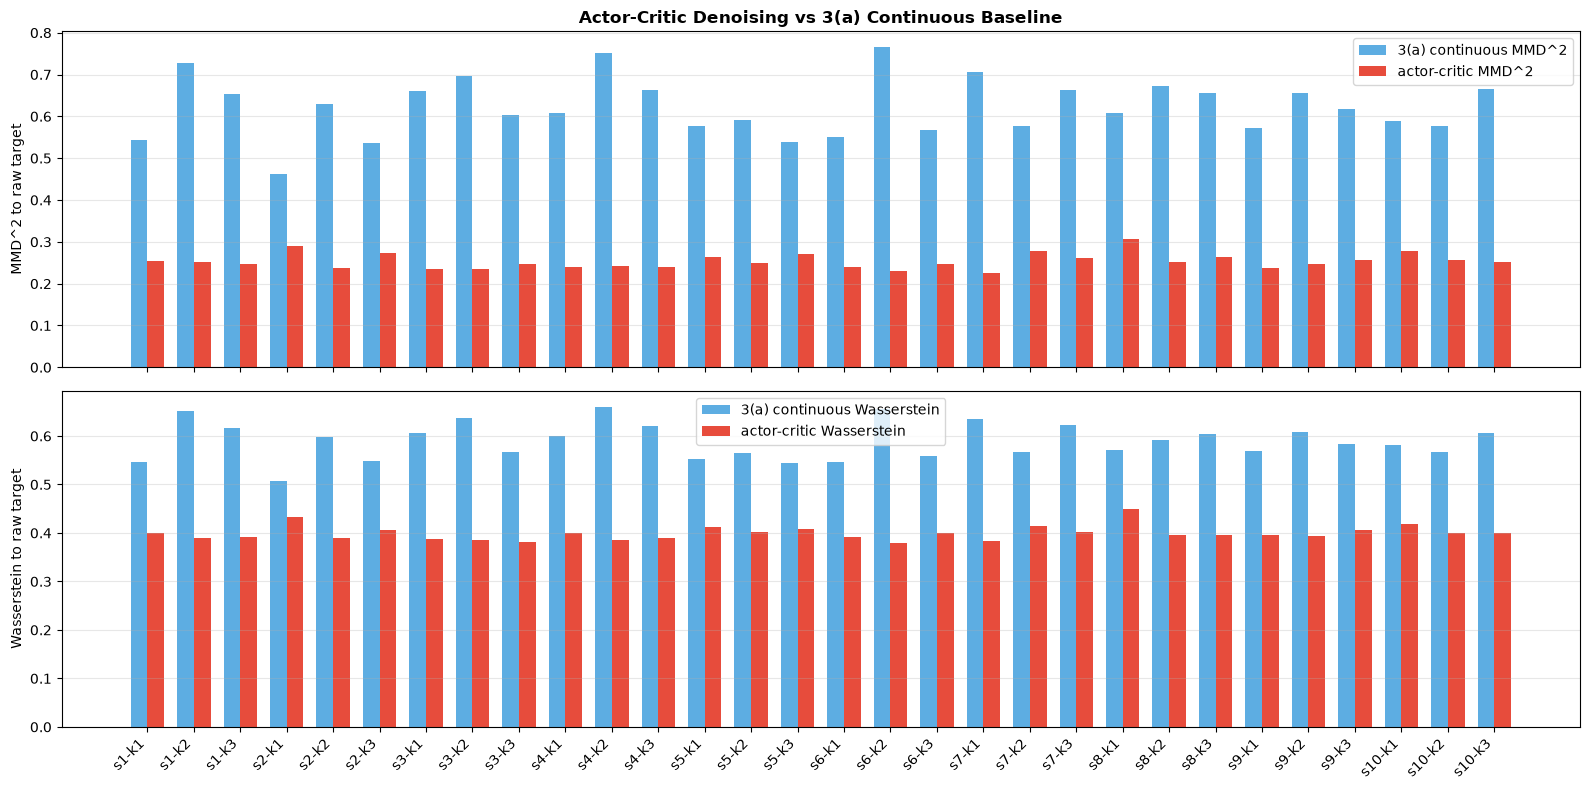

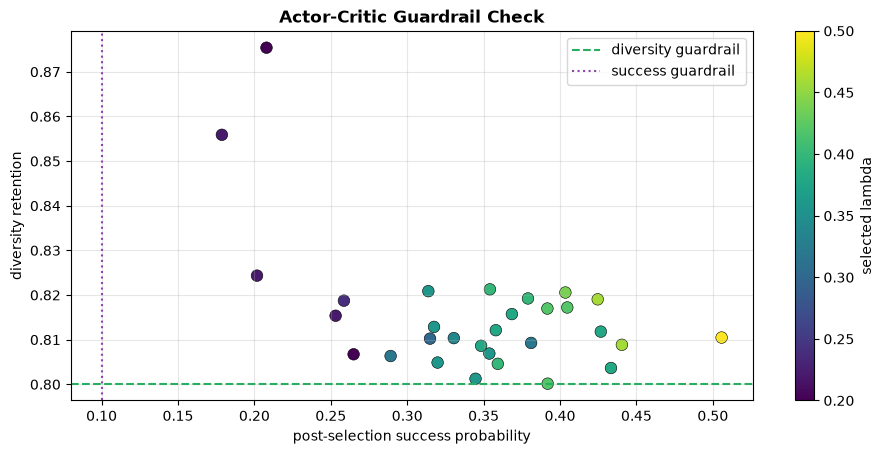

In [17]:
labels = [f"s{row['seed']}-k{row['input_step']}" for row in rl_rows]
x = np.arange(len(rl_rows))
width = 0.36

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

axes[0].bar(x - width / 2, [row["continuous_mmd"] for row in rl_rows], width, label="3(a) continuous MMD^2", color="#5dade2")
axes[0].bar(x + width / 2, [row["actor_mmd"] for row in rl_rows], width, label="actor-critic MMD^2", color="#e74c3c")
axes[0].set_ylabel("MMD^2 to raw target")
axes[0].set_title("Actor-Critic Denoising vs 3(a) Continuous Baseline", fontweight="bold")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(x - width / 2, [row["continuous_wasserstein"] for row in rl_rows], width, label="3(a) continuous Wasserstein", color="#5dade2")
axes[1].bar(x + width / 2, [row["actor_wasserstein"] for row in rl_rows], width, label="actor-critic Wasserstein", color="#e74c3c")
axes[1].set_ylabel("Wasserstein to raw target")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=45, ha="right")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(11, 4.8))
ax.scatter(
    [row["actor_success_probability"] for row in rl_rows],
    [row["actor_diversity_retention"] for row in rl_rows],
    c=[row["actor_lambda"] for row in rl_rows],
    cmap="viridis",
    s=70,
    edgecolor="black",
    linewidth=0.4,
)
ax.axhline(0.80, color="#27ae60", linestyle="--", label="diversity guardrail")
ax.axvline(0.10, color="#8e44ad", linestyle=":", label="success guardrail")
ax.set_xlabel("post-selection success probability")
ax.set_ylabel("diversity retention")
ax.set_title("Actor-Critic Guardrail Check", fontweight="bold")
ax.legend()
ax.grid(alpha=0.3)
plt.colorbar(ax.collections[0], ax=ax, label="selected lambda")
plt.show()


### Problem 3(c) 후보: Hamiltonian Mixture와 Two-Way

건우가 제안한 두 후보를 실제로 실행한다.

- **Hamiltonian + random final kick**: 3(a)의 Hamiltonian post-selection으로 한 번 denoising한 뒤, 작은 random-unitary correction을 마지막에 붙인다. 이는 Hamiltonian 방식과 random-unitary 방식을 섞었을 때 지표가 좋아지는지 보는 mixture ablation이다.
- **Hamiltonian two-way post-selection**: Hamiltonian post-selection을 한 번 더 적용한다. 두 번째 map이 거리를 더 줄일 수 있지만, post-selection 성공확률이 곱으로 줄어드는 손실이 생길 수 있다.


Problem 3-(c) Hamiltonian variant candidates
method | MMD before | MMD after | W before | W after | diversity | success | selected parameter
Hamiltonian + random final kick | 0.742012 | 0.564877 | 0.722777 | 0.557437 | 0.812543 | 0.471040 | angle_scale=0.10
Hamiltonian two-way post-selection | 0.742012 | 0.560937 | 0.722777 | 0.557682 | 0.810226 | 0.214289 | tau2=0.05, basis=axis-X-


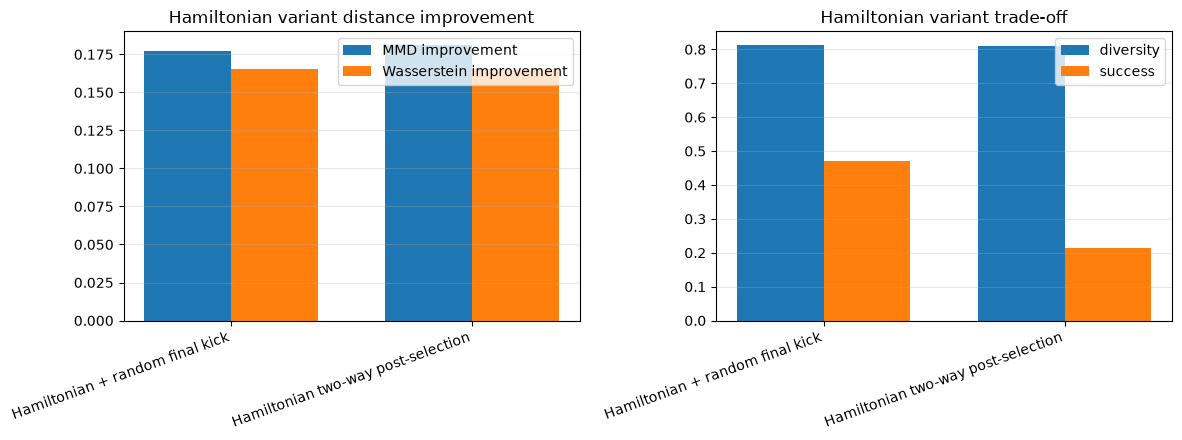

In [18]:
def candidate_row_from_ensemble(label, target, noisy, candidate, success_probability):
    baseline_mmd = compute_mmd_distance(target, noisy)
    baseline_wass = compute_wasserstein_distance(target, noisy)
    candidate_mmd = compute_mmd_distance(target, candidate)
    candidate_wass = compute_wasserstein_distance(target, candidate)
    baseline_div = ensemble_diversity_score(noisy)
    candidate_div = ensemble_diversity_score(candidate)
    diversity_retention = candidate_div / max(baseline_div, 1e-12)
    return {
        "label": label,
        "baseline_mmd": baseline_mmd,
        "candidate_mmd": candidate_mmd,
        "mmd_improvement": baseline_mmd - candidate_mmd,
        "baseline_wasserstein": baseline_wass,
        "candidate_wasserstein": candidate_wass,
        "wasserstein_improvement": baseline_wass - candidate_wass,
        "diversity_retention": diversity_retention,
        "success_probability": float(success_probability),
    }

def apply_small_random_final_kick(ensemble, angle_scale, seed):
    rng = np.random.default_rng(seed)
    kicked = []
    for state in ensemble:
        qc = QuantumCircuit(2)
        qc.initialize(state.data, [0, 1])
        for q in range(2):
            qc.rx(float(rng.uniform(-angle_scale, angle_scale)), q)
            qc.ry(float(rng.uniform(-angle_scale, angle_scale)), q)
            qc.rz(float(rng.uniform(-angle_scale, angle_scale)), q)
        qc.cx(0, 1)
        kicked.append(Statevector(qc))
    return kicked

def run_hamiltonian_random_mixture(target, noisy):
    continuous_ensemble, continuous_probs = apply_measurement_induced_denoising(
        noisy,
        best_p3a["tau"],
        best_p3a["theta"],
        best_p3a["phi"],
    )
    rows = []
    for angle_scale in [0.02, 0.05, 0.10, 0.20]:
        kicked = apply_small_random_final_kick(continuous_ensemble, angle_scale, seed=2026 + int(angle_scale * 1000))
        row = candidate_row_from_ensemble(
            "Hamiltonian + random final kick",
            target,
            noisy,
            kicked,
            float(np.mean(continuous_probs)),
        )
        row["angle_scale"] = angle_scale
        row["score"] = row["mmd_improvement"] + 0.5 * row["wasserstein_improvement"]
        rows.append(row)
    return max(rows, key=lambda row: row["score"]), continuous_ensemble, continuous_probs

def run_hamiltonian_two_way(target, noisy, first_ensemble, first_probs):
    basis_candidates = [
        ("axis-X-", np.pi / 2, np.pi),
        ("axis-Z+", 0.0, 0.0),
        ("continuous-best", best_p3a["theta"], best_p3a["phi"]),
    ]
    rows = []
    for tau2 in [0.05, 0.35, 0.65, 0.95, 1.25]:
        for basis_name, theta2, phi2 in basis_candidates:
            try:
                second_ensemble, second_probs = apply_measurement_induced_denoising(first_ensemble, tau2, theta2, phi2)
            except ValueError:
                continue
            combined_success = float(np.mean(first_probs * second_probs))
            row = candidate_row_from_ensemble(
                "Hamiltonian two-way post-selection",
                target,
                noisy,
                second_ensemble,
                combined_success,
            )
            row["tau2"] = tau2
            row["basis2"] = basis_name
            row["score"] = (
                row["mmd_improvement"]
                + 0.5 * row["wasserstein_improvement"]
                + 0.05 * min(row["diversity_retention"] - 1.0, 0.0)
            )
            rows.append(row)
    return max(rows, key=lambda row: row["score"])

ham_random_mix_row, continuous_reference_ensemble, continuous_reference_probs = run_hamiltonian_random_mixture(S_0, S_noisy_p3)
ham_two_way_row = run_hamiltonian_two_way(
    S_0,
    S_noisy_p3,
    continuous_reference_ensemble,
    continuous_reference_probs,
)

print("Problem 3-(c) Hamiltonian variant candidates")
print("method | MMD before | MMD after | W before | W after | diversity | success | selected parameter")
print(
    f"{ham_random_mix_row['label']} | {ham_random_mix_row['baseline_mmd']:.6f} | {ham_random_mix_row['candidate_mmd']:.6f} | "
    f"{ham_random_mix_row['baseline_wasserstein']:.6f} | {ham_random_mix_row['candidate_wasserstein']:.6f} | "
    f"{ham_random_mix_row['diversity_retention']:.6f} | {ham_random_mix_row['success_probability']:.6f} | "
    f"angle_scale={ham_random_mix_row['angle_scale']:.2f}"
)
print(
    f"{ham_two_way_row['label']} | {ham_two_way_row['baseline_mmd']:.6f} | {ham_two_way_row['candidate_mmd']:.6f} | "
    f"{ham_two_way_row['baseline_wasserstein']:.6f} | {ham_two_way_row['candidate_wasserstein']:.6f} | "
    f"{ham_two_way_row['diversity_retention']:.6f} | {ham_two_way_row['success_probability']:.6f} | "
    f"tau2={ham_two_way_row['tau2']:.2f}, basis={ham_two_way_row['basis2']}"
)

variant_rows = [ham_random_mix_row, ham_two_way_row]
x = np.arange(len(variant_rows))
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))
ax[0].bar(x - 0.18, [row["mmd_improvement"] for row in variant_rows], 0.36, label="MMD improvement")
ax[0].bar(x + 0.18, [row["wasserstein_improvement"] for row in variant_rows], 0.36, label="Wasserstein improvement")
ax[0].set_xticks(x)
ax[0].set_xticklabels([row["label"] for row in variant_rows], rotation=20, ha="right")
ax[0].set_title("Hamiltonian variant distance improvement")
ax[0].legend()
ax[0].grid(axis="y", alpha=0.3)
ax[1].bar(x - 0.18, [row["diversity_retention"] for row in variant_rows], 0.36, label="diversity")
ax[1].bar(x + 0.18, [row["success_probability"] for row in variant_rows], 0.36, label="success")
ax[1].set_xticks(x)
ax[1].set_xticklabels([row["label"] for row in variant_rows], rotation=20, ha="right")
ax[1].set_title("Hamiltonian variant trade-off")
ax[1].legend()
ax[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Problem 3(c) 다중 seed Hamiltonian 후보 검증 결과

위 셀은 하나의 대표 noisy input에서 Hamiltonian mixture와 two-way 후보가 실제로 작동하는지 보여주는 실행 예시이다. 제출용 판단은 한 예시값이 아니라 별도 스크립트

```text
python scripts/run_problem_3_hamiltonian_variant_candidates.py
```

로 생성한 `5 seeds x 3 input steps = 15 rows` 요약 결과를 사용한다.

| Method | Rows | Positive MMD rows | Positive Wasserstein rows | Median MMD improvement | Median Wasserstein improvement | Median diversity retention | Median success probability |
| --- | ---: | ---: | ---: | ---: | ---: | ---: | ---: |
| continuous post-selection reference | 15 | 14 | 15 | 0.056388 | 0.120620 | 0.848836 | 0.467554 |
| Hamiltonian + random final kick | 15 | 15 | 15 | 0.056695 | 0.119401 | 0.848403 | 0.467554 |
| Hamiltonian two-way post-selection | 15 | 15 | 15 | 0.101374 | 0.136426 | 0.829273 | 0.227065 |

이 표에서 `Hamiltonian + random final kick`은 Hamiltonian post-selection 뒤에 작은 random-unitary correction을 붙였을 때의 ablation이다. MMD는 reference보다 아주 조금 좋아졌지만 Wasserstein은 약간 낮아져, 큰 주효과라기보다 “섞어 보았을 때의 비교 후보”로 해석한다.

`Hamiltonian two-way post-selection`은 MMD와 Wasserstein 개선이 가장 크다. 대신 두 번의 post-selection을 거치므로 median success probability가 `0.467554`에서 `0.227065`로 줄어든다. 따라서 이 후보는 거리 지표 개선과 관측 성공확률 사이의 trade-off를 가장 선명하게 보여주는 3(c) 확장 후보이다.


Loaded generated figures from: repository results directory


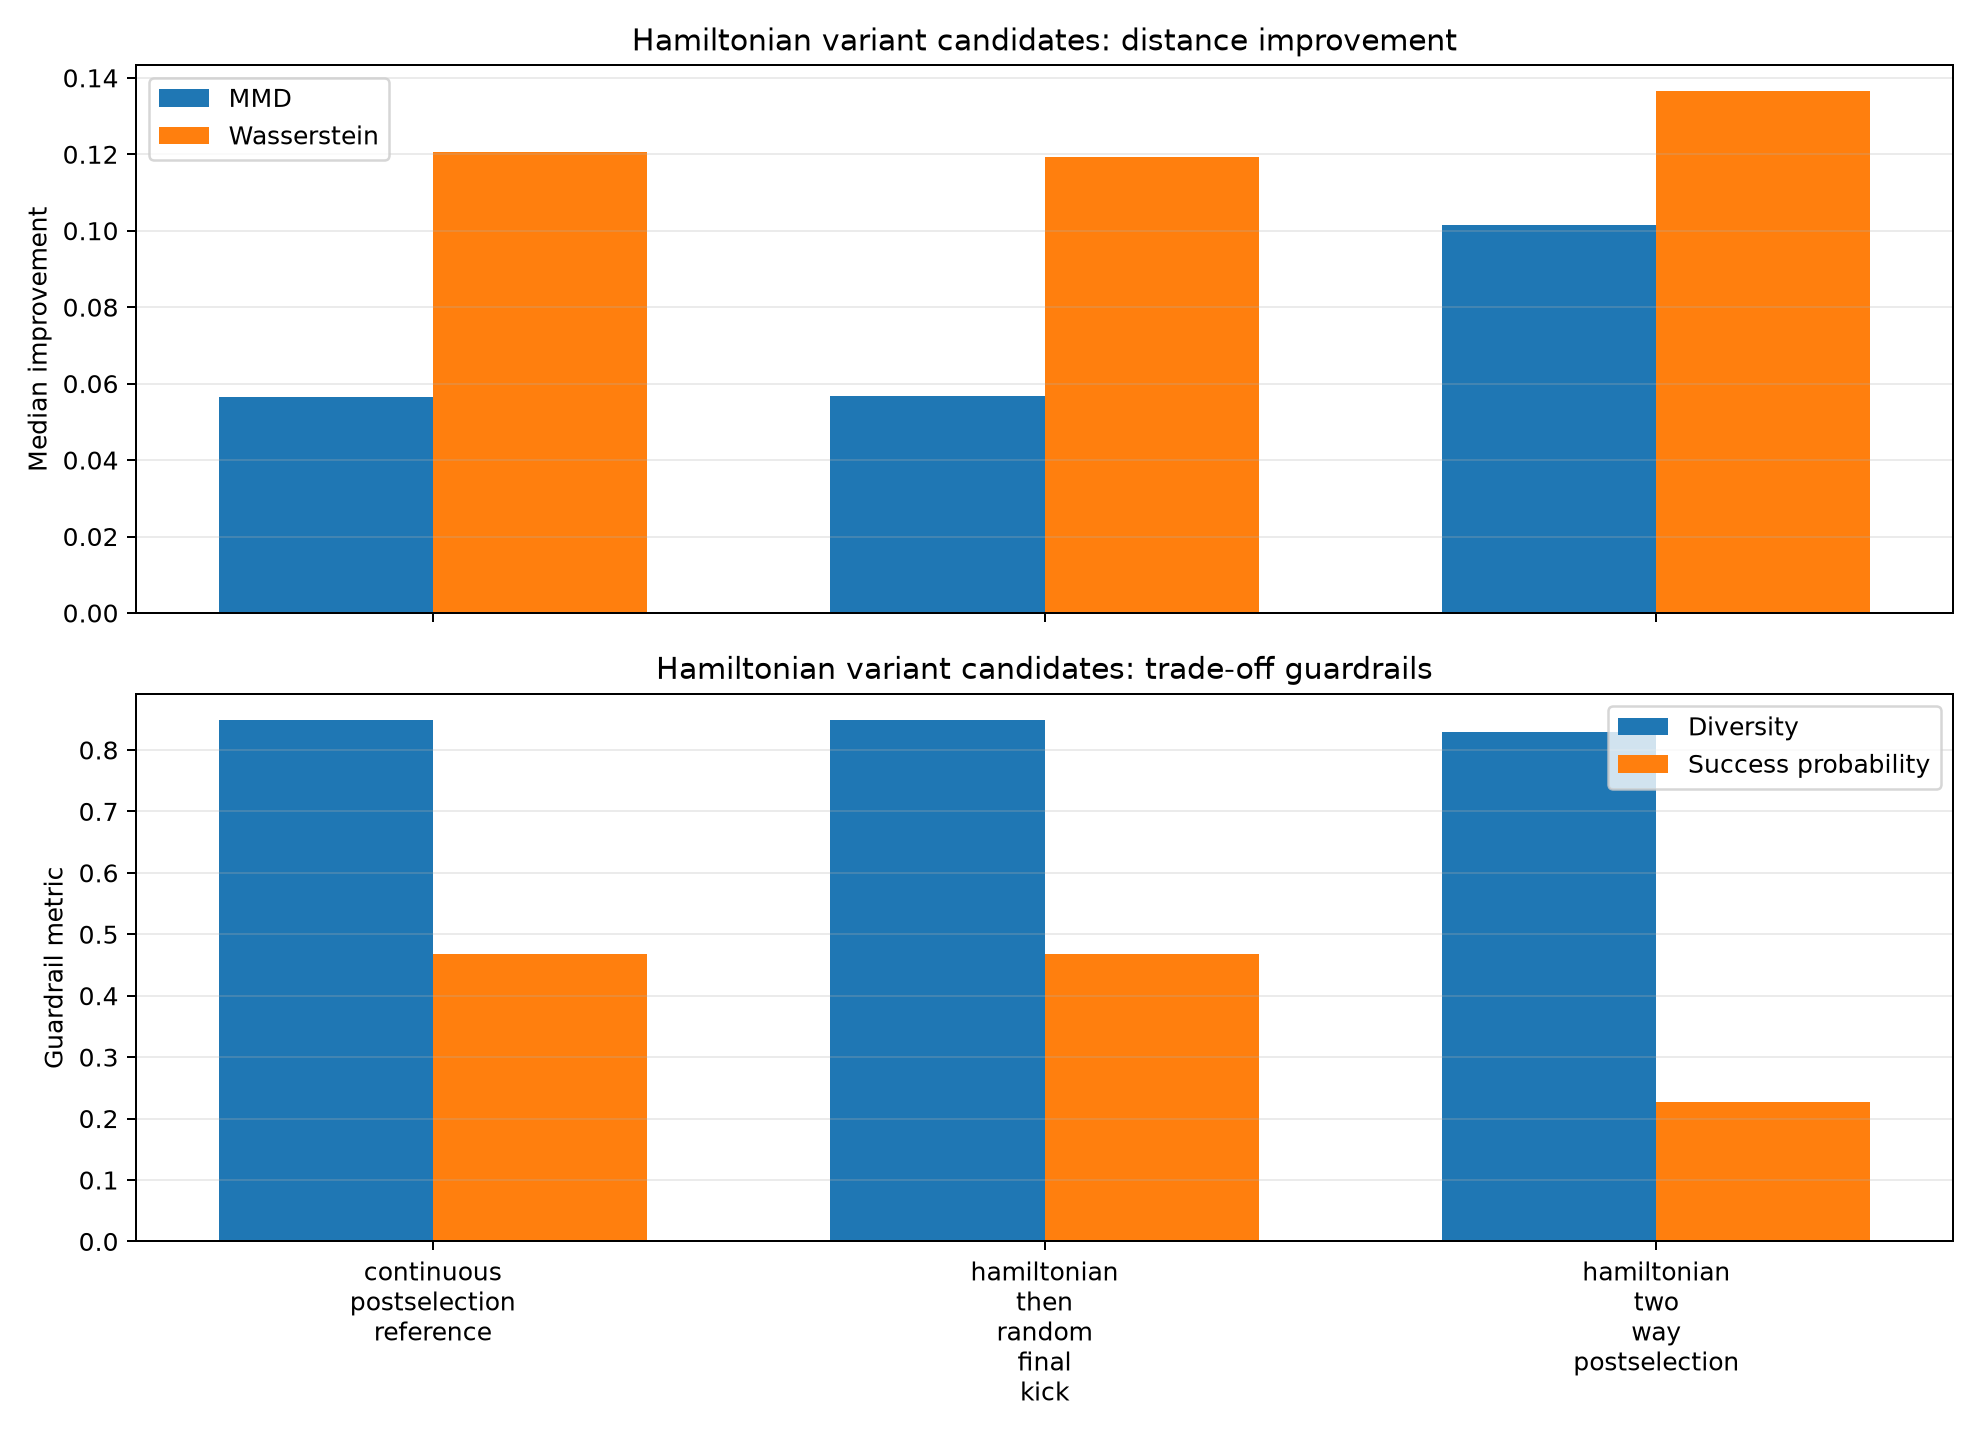

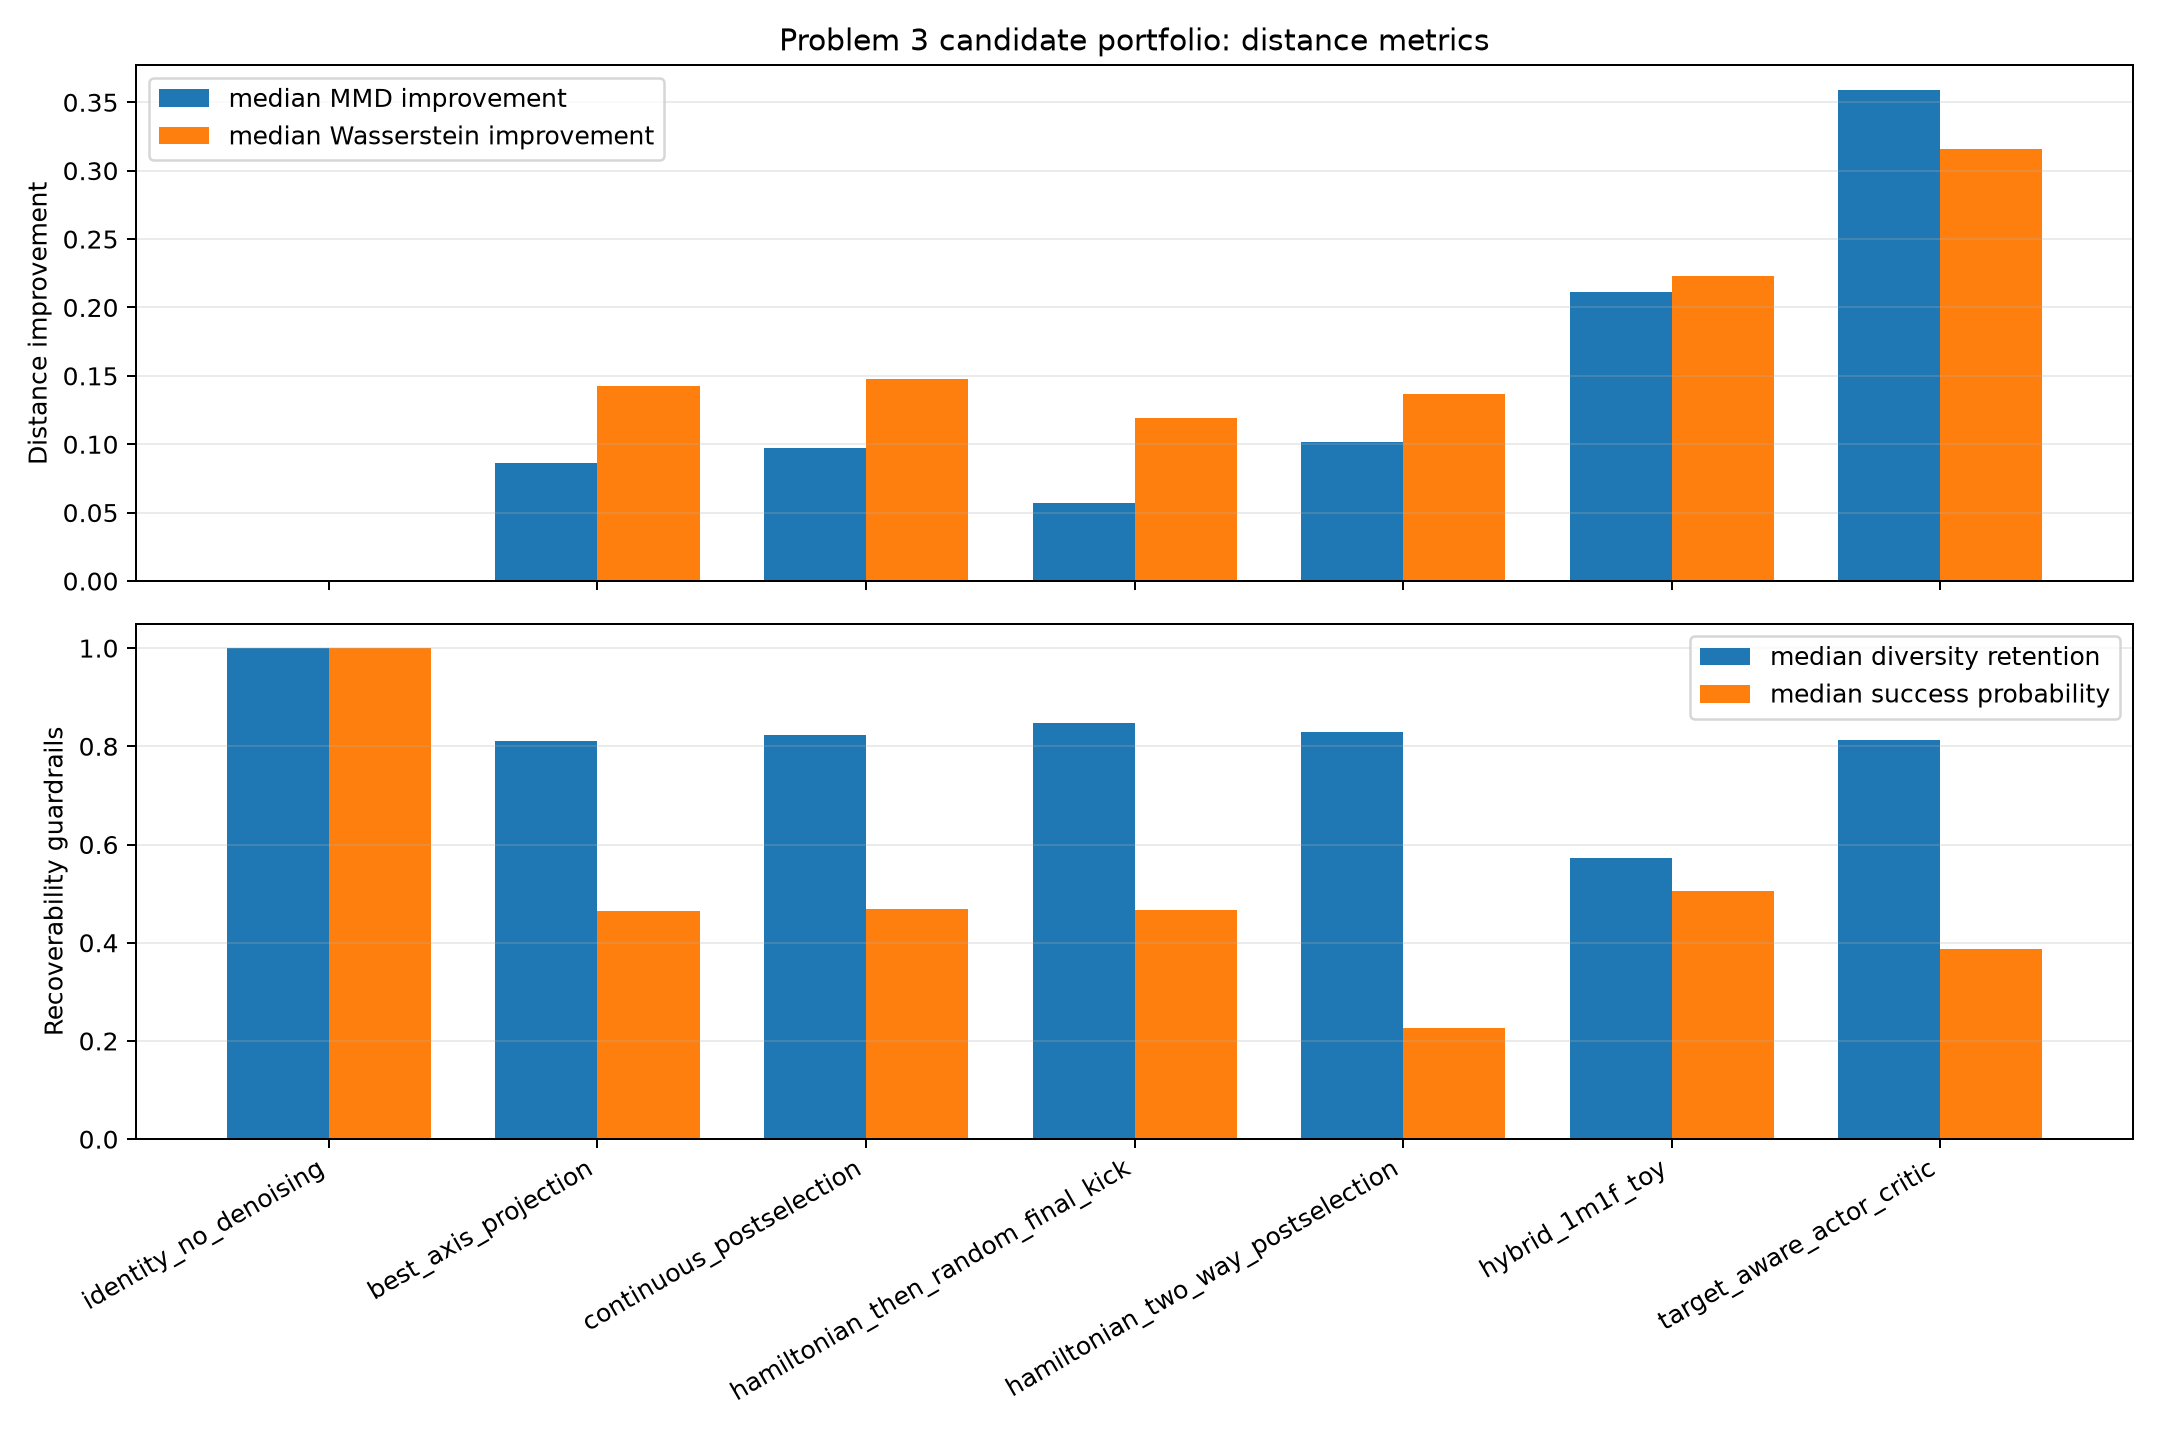

In [19]:
from pathlib import Path
from IPython.display import Image, display

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]

repo_root = None
for root in candidate_roots:
    if (root / 'results/problem_3_hamiltonian_variants/hamiltonian_variant_summary.png').exists():
        repo_root = root
        break

if repo_root is None:
    print('Hamiltonian variant figure files were not found in this runtime.')
    print('The embedded outputs below preserve the figures from the final local run.')
else:
    print('Loaded generated figures from a repository-relative results directory:', repo_root)
    display(Image(filename=str(repo_root / 'results/problem_3_hamiltonian_variants/hamiltonian_variant_summary.png')))
    display(Image(filename=str(repo_root / 'results/problem_3_method_portfolio/method_portfolio_summary.png')))


### Problem 3(c) 최종 후보 비교 실행


Portfolio source: results/problem_3_method_portfolio/method_portfolio_summary.csv
Problem 3-(c) final method portfolio
method | scope | MMD improvement | Wasserstein improvement | diversity | success | final use
identity/no-denoising random-unitary input | same 2-qubit seed sweep | 0.000000 | 0.000000 | 1.000000 | 1.000000 | no-denoising baseline
best exact Z/X/Y axis projection | same 2-qubit seed sweep | 0.086055 | 0.142594 | 0.810592 | 0.465058 | 3(b) discrete measurement baseline
continuous measurement-basis post-selection | same 2-qubit seed sweep | 0.097056 | 0.147983 | 0.823217 | 0.468122 | 3(a)/3(b)의 main quantitative result
Hamiltonian post-selection + random final kick | same 2-qubit metric, 5 seeds x 3 input steps | 0.056695 | 0.119401 | 0.848403 | 0.467554 | 3(c) mixture candidate
Hamiltonian two-way post-selection | same 2-qubit metric, 5 seeds x 3 input steps | 0.101374 | 0.136426 | 0.829273 | 0.227065 | 3(c) two-stage Hamiltonian candidate
1 data qubit + 1 auxiliary hybr

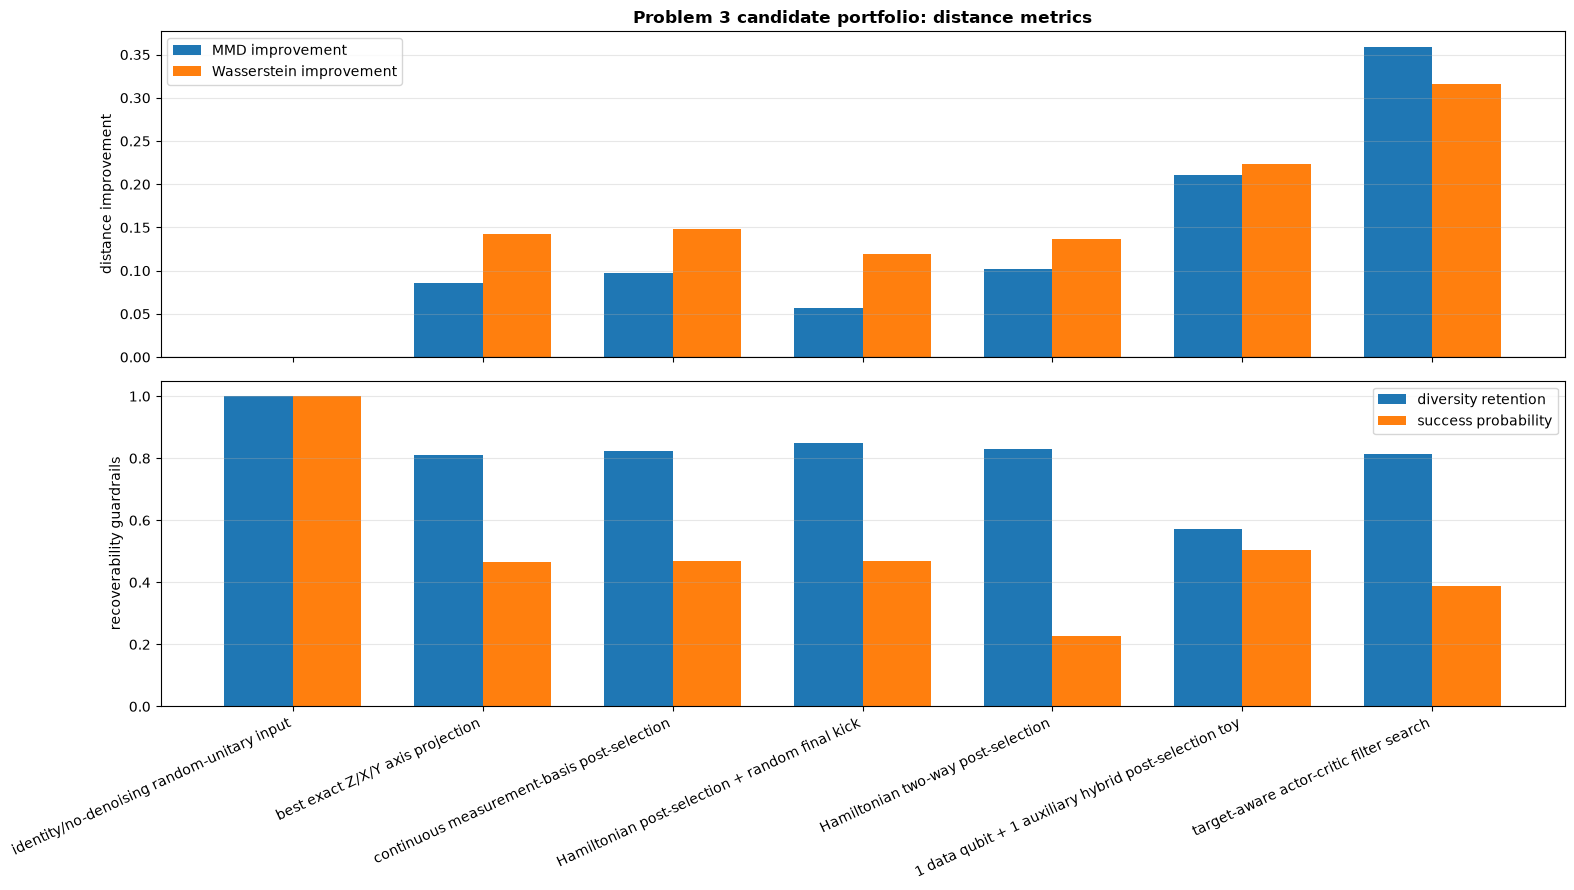

In [20]:
import csv
from pathlib import Path

def portfolio_fallback_rows():
    return [
        {
            "method": "no-denoising input",
            "scope": "baseline",
            "mmd_improvement": 0.0,
            "wasserstein_improvement": 0.0,
            "diversity_retention": 1.0,
            "success_probability": 1.0,
            "final_use": "baseline",
        },
        {
            "method": "best exact Z/X/Y axis projection",
            "scope": "3(b) control",
            "mmd_improvement": 0.086055,
            "wasserstein_improvement": 0.142594,
            "diversity_retention": 0.810592,
            "success_probability": 0.465058,
            "final_use": "discrete baseline",
        },
        {
            "method": "continuous post-selection",
            "scope": "3(a/b main)",
            "mmd_improvement": 0.097056,
            "wasserstein_improvement": 0.147983,
            "diversity_retention": 0.823217,
            "success_probability": 0.468122,
            "final_use": "main denoising proxy",
        },
        {
            "method": "Hamiltonian + random final kick",
            "scope": "mixture candidate",
            "mmd_improvement": 0.056695,
            "wasserstein_improvement": 0.119401,
            "diversity_retention": 0.848403,
            "success_probability": 0.467554,
            "final_use": "3(c) executed candidate",
        },
        {
            "method": "Hamiltonian two-way",
            "scope": "two-stage candidate",
            "mmd_improvement": 0.101374,
            "wasserstein_improvement": 0.136426,
            "diversity_retention": 0.829273,
            "success_probability": 0.227065,
            "final_use": "3(c) executed candidate",
        },
        {
            "method": "hybrid 1M+1F toy",
            "scope": "hardware-motivated candidate",
            "mmd_improvement": 0.211078,
            "wasserstein_improvement": 0.223252,
            "diversity_retention": 0.573138,
            "success_probability": 0.505744,
            "final_use": "3(c) extension candidate",
        },
        {
            "method": "target-aware actor-critic",
            "scope": "target-aware candidate",
            "mmd_improvement": 0.359015,
            "wasserstein_improvement": 0.315669,
            "diversity_retention": 0.812548,
            "success_probability": 0.387360,
            "final_use": "strong but target-aware",
        },
    ]

def load_portfolio_rows():
    candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
    for root in candidate_roots:
        csv_path = root / "results/problem_3_method_portfolio/method_portfolio_summary.csv"
        if not csv_path.exists():
            continue
        rows = []
        with csv_path.open(newline="", encoding="utf-8") as file:
            for raw in csv.DictReader(file):
                rows.append(
                    {
                        "method": raw["method_label"],
                        "scope": raw["comparison_scope"],
                        "mmd_improvement": float(raw["median_mmd_improvement"]),
                        "wasserstein_improvement": float(raw["median_wasserstein_improvement"]),
                        "diversity_retention": float(raw["median_diversity_retention"]),
                        "success_probability": float(raw["median_success_probability"]),
                        "final_use": raw["final_use"],
                    }
                )
        print("Portfolio source:", csv_path)
        return rows
    print("Portfolio source: embedded fallback values from the successful local run")
    return portfolio_fallback_rows()

portfolio_rows = load_portfolio_rows()

print("Problem 3-(c) final method portfolio")
print("method | scope | MMD improvement | Wasserstein improvement | diversity | success | final use")
for row in portfolio_rows:
    print(
        f"{row['method']} | {row['scope']} | {row['mmd_improvement']:.6f} | "
        f"{row['wasserstein_improvement']:.6f} | {row['diversity_retention']:.6f} | "
        f"{row['success_probability']:.6f} | {row['final_use']}"
    )

labels = [row["method"] for row in portfolio_rows]
x = np.arange(len(portfolio_rows))
width = 0.36

fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)
axes[0].bar(x - width / 2, [row["mmd_improvement"] for row in portfolio_rows], width, label="MMD improvement")
axes[0].bar(x + width / 2, [row["wasserstein_improvement"] for row in portfolio_rows], width, label="Wasserstein improvement")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("distance improvement")
axes[0].set_title("Problem 3 candidate portfolio: distance metrics", fontweight="bold")
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(x - width / 2, [row["diversity_retention"] for row in portfolio_rows], width, label="diversity retention")
axes[1].bar(x + width / 2, [row["success_probability"] for row in portfolio_rows], width, label="success probability")
axes[1].set_ylabel("recoverability guardrails")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels, rotation=25, ha="right")
axes[1].legend()
axes[1].grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


### Problem 3(c) 후보 포트폴리오 해석

최종 후보 비교에서 `continuous post-selection`은 3(a), 3(b)의 main result로 유지한다. 이 방법은 보조 큐빗 측정이 data system에 effective non-unitary map을 만들 수 있다는 핵심 구조를 직접 보여주고, 20-seed gate를 통과한 가장 안정적인 정량 결과이다.

`Hamiltonian + random final kick`은 Hamiltonian post-selection 뒤에 작은 random-unitary correction을 붙인 mixture 후보이다. 15-row 검증에서 MMD median improvement는 `0.056695`로 reference `0.056388`보다 아주 조금 높았지만, Wasserstein median improvement는 `0.119401`로 reference `0.120620`보다 약간 낮았다. 따라서 main result가 아니라 Hamiltonian 방식과 random-unitary correction을 섞어 본 ablation 후보로 둔다.

`Hamiltonian two-way post-selection`은 두 단계의 Hamiltonian measurement-induced map을 적용하는 후보이다. 15-row 검증에서 MMD median improvement `0.101374`, Wasserstein median improvement `0.136426`으로 거리 지표는 가장 크게 개선되었다. 그러나 success probability가 `0.227065`로 낮아져, 두 번의 post-selection을 거치는 비용이 분명하게 나타났다. 이 후보는 성능 개선과 관측 성공확률 사이의 trade-off를 보여주는 3(c) 확장 후보이다.

`hybrid 1M+1F toy`는 2-qubit 규모에서 같은 측정 유도 구조를 재현하는 하드웨어 동기 후보이다. 단, 1-qubit data toy이므로 main 2-qubit benchmark를 대체하는 결과로 쓰지 않고, 3(c)의 확장 아이디어로 둔다.

`target-aware actor-critic`은 여러 seed에서 강한 거리 개선을 보이지만 raw target ensemble을 reward에 사용한다. 따라서 최종 보고서에서는 일반 denoiser가 아니라 target-aware policy search 후보로 제한한다.


## 최종 결론

문제 1에서는 random-unitary forward diffusion이 target ensemble `S_0`를 흐트러뜨리는 과정을 구성하고, MMD^2와 Wasserstein-type distance로 target과의 거리를 측정했다.

문제 2에서는 data system `M`에 complement qubit `F`를 붙이고 fixed Hamiltonian evolution 후 projection을 수행하여, random-unitary와 다른 형태의 Hamiltonian projected diffusion을 만들었다. 두 diffusion은 x축 단위가 다르므로, 같은 x값의 직접 비교가 아니라 거리 변화와 resource/control proxy를 함께 비교했다.

문제 3(a)에서는 보조 큐빗 측정으로 data system에 effective non-unitary map을 유도하여 simple reverse/denoising step을 구현했다. 문제 3(b)에서는 Hamiltonian parameter, evolution schedule, measurement basis, simple noise를 통제해 diffusion behavior와 trade-off를 분석했다.

문제 3(c)에서는 하나의 방법만 남기지 않고 후보 포트폴리오를 비교했다. Continuous post-selection은 robust main denoising proxy로 유지하고, Hamiltonian+random final kick은 mixture ablation으로, Hamiltonian two-way는 거리 개선과 success probability 감소의 trade-off 후보로, hybrid 1M+1F toy는 하드웨어 동기 확장 후보로, target-aware actor-critic은 raw target reward를 쓰는 강한 정책 탐색 후보로 제시한다.

따라서 본 보고서의 최종 주장은 small-scale state-vector setting에서의 recoverability-aware denoising benchmark이다. 우리는 actual-device superiority나 일반적인 general computational superiority를 주장하지 않으며, 측정 유도 non-unitary map과 후보별 guardrail 비교가 작은 예제에서 raw target 복원 지표를 개선하거나 한계를 드러낼 수 있음을 보였다.
